In [163]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata
import re

Datos de ingreso

In [164]:
#Filtros de fechas

dia_ivd = '20260301'
dia_fvd = '20260331'

dia_ias = '01-03-2026'
dia_fas = '31-03-2026'

dia_if = '2026-03-01'
dia_ff = '2026-03-31'

mes = 'Novedades_mar26'

mes_i = 'mar26'

total_dias_julio = 31

mes_c = 'Marzo'

mes = 'marzo'

In [165]:
#Informes de turnos, tipo día, personal

turno_via = pd.read_csv("C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Indicadores/Base_indicadores/turnos_via_fms.csv", sep=';')

turno_sup = pd.read_csv("C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Indicadores/Base_indicadores/turnos_supervisor_fms.csv", sep=';')

tipo_dia = pd.read_csv("Z:/01 base_datos/41 Informe Diario CCZ/2023/IRI TM/Tipo día.csv", encoding='latin',delimiter=';')

personal = pd.read_csv("Z:/01 base_datos/41 Informe Diario CCZ/2023/IRI TM/Personal_id.csv",encoding='latin',delimiter=';')

turno_ccz = pd.read_csv("C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Indicadores/Base_indicadores/turnos_control_fms_2026.csv", sep=';')

turno_moto_aux = pd.read_csv("C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Indicadores/Base_indicadores/turnos_motoregulador_fms.csv", sep=';')

turno_aux = pd.read_csv("C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Indicadores/Base_indicadores/turnos_aux_fms.csv", sep=';')

In [166]:
# Convertir la columna 'Fecha' al formato de fecha y luego formatearla como 'dd/MM/yyyy' en tipo día
tipo_dia['Fecha'] = pd.to_datetime(tipo_dia['Fecha'], format='%d/%m/%Y', errors='coerce')

# Formatear la fecha para que siempre tenga dos dígitos en día y mes
tipo_dia['Fecha'] = tipo_dia['Fecha'].dt.strftime('%d/%m/%Y')

# Verificar el resultado
tipo_dia.head()

,Fecha,Día,Tipo Día
0,01/01/2016,Viernes,Festivo
1,02/01/2016,Sábado,Sábado
2,03/01/2016,Domingo,Festivo
3,04/01/2016,Lunes,Hábil
4,05/01/2016,Martes,Hábil


In [167]:
#Crear dataframe para llevar el nombre a fonias

# Crear un diccionario con los datos
data = {
    'RegC': [
        'Luis Fernando Gonzalez', 'William Munar Gonzalez', 'Adriana Patricia Tellez',
        'Jose Antonio Castro Garcia', 'Rosa Tellez', 'Edith Patarroyo',
        'Laura Marcela Vargas Gutierrez', 'Francy Linnie Timaran Cuesta', 
        'Yerly Irene Hernandez Ariza', 'Anderson Mizar Mendoza', 'Jorge Medina Espinoza',
        'Esteban Camilo Medina', 'Sandra Carolina Valeriano', 'Julian Andres Sanchez Restrepo',
        'Karen Lorena Barrera', 'Bryan Guzman', 'Jinneth Alexandra Guzman',
        'Maicol Alexander Pita Blanco', 'Martha Ibeth Martin', 'John Jairo Espinosa Santa',
        'Elicia Mongui Duarte', 'Sonia Constanza Correa Rodriguez', 'Jenny Alexandra Bernal',
        'Norberto Niño Rodriguez', 'Wilson Torres Fajardo', 'William Ignacio Valderrama',
        'Camilo Andres Lopez Penagos', 'Raúl Fabián Romero Micán', 'Deisi Yanira Rojas Torres',
        'Paula Katherine Cantor Salamanca','Angela Mireya Riaño Pasito'
    ],
    'RegControl': [
        'LUIS FERNANDO GONZALEZ REYES', 'WILLIAN HUMBERTO MUNAR GONZALEZ', 
        'ADRIANA PATRICIA TELLEZ VARELA', 'JOSE ANTONIO CASTRO GARCIA', 
        'ROSA MARIELA TELLEZ NAVARRO', 'DORIS EDITH PATARROYO GORDO',
        'LAURA MARCELA VARGAS GUTIERREZ', 'FRANCY LINNE TIMARAN CUESTA', 
        'YERLI IRENE HERNÁNDEZ ARIZA', 'ANDERSON MIZAR MENDOZA', 
        'JORGE MEDINA ESPINOSA', 'ESTEBAN CAMILO MEDINA', 
        'SANDRA CAROLINA VALERIANO SARMIENTO', 'JULIAN ANDRES SANCHEZ RESTREPO', 
        'KAREN LORENA BARRERA SERRANO', 'BRYAN ANDRES GUZMAN ROJANO', 
        'JINETH ALEXANDRA GUZMAN HERNANDEZ', 'MAICOL ALEXANDER PITA BLANCO', 
        'MARTHA IBETH MARTIN MARTIN', 'JOHN JAIRO ESPINOSA SANTA', 
        'ELICIA MONGUI DUARTE', 'SONIA CONSTANZA CORREA RODRIGUEZ', 
        'JENNY ALEXANDRA BERNAL BERNAL', 'NORBERTO NIÑO RODRIGUEZ', 
        'WILSON ABEL TORRES FAJARDO', 'WILLIAM IGNACIO VALDERRAMA GONZALEZ', 
        'CAMILO ANDRES LOPEZ PENAGOS', 'RAUL FABIAN ROMERO MICAN', 
        'DEISY YANIRA ROJAS TORRES', 'PAULA KATHERINE CANTOR SALAMANCA',
        'ANGELA MIREYA RIAÑO PASITO'
    ]
}

# Convertir el diccionario a un DataFrame
base = pd.DataFrame(data)

# Mostrar el DataFrame
base.head()

,RegC,RegControl
0,Luis Fernando Gonzalez,LUIS FERNANDO GONZALEZ REYES
1,William Munar Gonzalez,WILLIAN HUMBERTO MUNAR GONZALEZ
2,Adriana Patricia Tellez,ADRIANA PATRICIA TELLEZ VARELA
3,Jose Antonio Castro Garcia,JOSE ANTONIO CASTRO GARCIA
4,Rosa Tellez,ROSA MARIELA TELLEZ NAVARRO


Asistencia

In [168]:
# Ruta de la carpeta que contiene los archivos de desglosados zonal
ruta_carpeta = f'Z:/01 base_datos/41 Informe Diario CCZ/Blogger/Asistencia/2026/{mes_c}'

# Fechas de inicio y fin para el filtro
fecha_inicio = f'{dia_ias}'
fecha_fin = f'{dia_fas}'

# Lista para almacenar los DataFrames
dataframes = []

# Recorrer todos los archivos en la carpeta
for nombre_archivo in os.listdir(ruta_carpeta):
    if nombre_archivo.endswith('.csv'):
        # Extraer la fecha del nombre del archivo
        fecha_archivo = nombre_archivo[:10]  
        
        # Convertir la fecha a un formato adecuado para comparación
        fecha_archivo_dt = pd.to_datetime(fecha_archivo, format='%d-%m-%Y', errors='coerce')

        # Verificar si la fecha está dentro del rango deseado
        if fecha_inicio <= fecha_archivo <= fecha_fin:
            ruta_archivo = os.path.join(ruta_carpeta, nombre_archivo)
            # Leer el archivo CSV omitiendo la primera fila vacía
            df = pd.read_csv(ruta_archivo, encoding='latin', delimiter=';',skiprows=2, low_memory=False)
             # Eliminar filas que estén completamente vacías
            df = df.dropna(how='all')
            # Añadir una nueva columna 'Fecha' con la fecha extraída del nombre del archivo
            df['Fecha'] = fecha_archivo
            dataframes.append(df)

# Verificar si se encontraron DataFrames
if dataframes:
    # Consolidar todos los DataFrames en uno solo
    asistencia = pd.concat(dataframes, ignore_index=True)

    # Guardar el DataFrame consolidado en un nuevo archivo
    asistencia.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Indicadores/Indicadores_python/asistencia_{mes_i}.csv', index=False)
else:
    print("No se encontraron archivos para consolidar.")
    
asistencia.head()

,NOMBRE,NOMBRE.1,APELLIDOS,TURNO Programado,Sitio Programado,Hora Inicio Programado,Hora Inicio Referencia Ajustado,Hora Inicio Real,Duración Programado,Hora Fin Programado,...,Hora Fin Real,HTL,Sitio Real,Aplica novedad,Informa,Tipo de novedad,Supervisor,Observaciones,INTRANET,Fecha
0,ADRIANA YANETH RAMIREZ GALVAN,ADRIANA YANETH,RAMIREZ GALVAN,PLA1,Portal Dorado,05:00:00,NaN,05:01:00,09:00:00,14:00:00,...,13:54:00,00:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01-03-2026
1,LEIDY TATIANA SANCHEZ VELANDIA,LEIDY TATIANA,SANCHEZ VELANDIA,PLA3,Portal 80,05:00:00,NaN,05:00:00,09:00:00,14:00:00,...,13:59:00,00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01-03-2026
2,CAMILO ANDRES LOPEZ PENAGOS,CAMILO ANDRES,LOPEZ PENAGOS,SUP CCZ,Disponible CCZ,06:00:00,06:00:00,06:00:00,16:00:00,22:00:00,...,22:00:00,00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01-03-2026
3,GLORIA ESPERANZA MESA REYES,GLORIA ESPERANZA,MESA REYES,EG5,Verbena III,06:00:00,NaN,05:57:00,08:00:00,14:00:00,...,13:54:00,00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01-03-2026
4,AMANDA PATRICIA RODRIGUEZ HERNANDEZ,AMANDA PATRICIA,RODRIGUEZ HERNANDEZ,EG9,Gaco II,06:00:00,NaN,05:56:00,08:00:00,14:00:00,...,13:56:00,00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01-03-2026


In [169]:
## Convertir la columna 'Fecha' al formato de fecha y luego formatearla como 'dd/MM/yyyy' en asistencia

# Convertir la columna 'Fecha' a tipo datetime
asistencia['Fecha'] = pd.to_datetime(asistencia['Fecha'], format='%d-%m-%Y')

# Formatear la columna 'Fecha' en el formato dd/mm/yyyy
asistencia['Fecha'] = asistencia['Fecha'].dt.strftime('%d/%m/%Y')

asistencia.head(2)

,NOMBRE,NOMBRE.1,APELLIDOS,TURNO Programado,Sitio Programado,Hora Inicio Programado,Hora Inicio Referencia Ajustado,Hora Inicio Real,Duración Programado,Hora Fin Programado,...,Hora Fin Real,HTL,Sitio Real,Aplica novedad,Informa,Tipo de novedad,Supervisor,Observaciones,INTRANET,Fecha
0,ADRIANA YANETH RAMIREZ GALVAN,ADRIANA YANETH,RAMIREZ GALVAN,PLA1,Portal Dorado,05:00:00,NaN,05:01:00,09:00:00,14:00:00,...,13:54:00,00:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/03/2026
1,LEIDY TATIANA SANCHEZ VELANDIA,LEIDY TATIANA,SANCHEZ VELANDIA,PLA3,Portal 80,05:00:00,NaN,05:00:00,09:00:00,14:00:00,...,13:59:00,00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/03/2026


Actividad de bus

In [170]:
#Importar archivos de F3 - Zonal FMS

carpeta_origen = r'Z:/01 base_datos/03 actividad_bus_FMS'

dataframes = [] 

fecha_inicio = pd.to_datetime(dia_ivd, format='%Y%m%d')
fecha_fin = pd.to_datetime(dia_fvd, format='%Y%m%d')

for archivo in os.listdir(carpeta_origen):
    if archivo.endswith('_actividad_bus.csv'):
        ruta_archivo = os.path.join(carpeta_origen, archivo)
        df = pd.read_csv(ruta_archivo, encoding='latin',low_memory=False)
        
        # Obtener la fecha del nombre del archivo
        fecha_archivo = pd.to_datetime(archivo.split('_')[0], format='%Y%m%d', errors='coerce')

        # Filtrar por fechas
        if fecha_archivo >= pd.to_datetime(fecha_inicio, format='%d/%m/%Y') and fecha_archivo <= pd.to_datetime(fecha_fin, format='%d/%m/%Y'):
            dataframes.append(df)  # Agregar el DataFrame a la lista

# Combinar todos los DataFrames en uno solo
if dataframes:
    vd_zonal = pd.concat(dataframes)

else:
    print("No se encontraron archivos que cumplan con el filtro de fechas.")
    
vd_zonal.head()

,Fecha,Concesión,Concesionario de Operación,Id Línea,Línea,Id Ruta,Ruta,Tabla,Viaje Linea,Orden Viaje,...,Nombre de Conductor,Evento,Hora Teórica,Hora Referencia,Hora Llegada,Hora Salida,Tiempo entre paradas,Alarma Exceso de Tiempo en Parada,Tiempo Apertura de Puertas,Lista de acciones regulatorias
0,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,JOSE ESNEIDER CABANZO AGUILAR,Inicio Viaje - Linea(11),15:59:12,17:21:00,17:13:20,17:13:20,NaN,NaN,0:00:00,NaN
1,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,JOSE ESNEIDER CABANZO AGUILAR,NaN,15:59:40,15:59:40,NaN,NaN,NaN,NaN,NaN,NaN
2,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,JOSE ESNEIDER CABANZO AGUILAR,NaN,16:00:01,16:00:01,NaN,NaN,NaN,NaN,NaN,NaN
3,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,JOSE ESNEIDER CABANZO AGUILAR,NaN,16:00:24,16:00:24,NaN,NaN,NaN,NaN,NaN,NaN
4,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,JOSE ESNEIDER CABANZO AGUILAR,NaN,16:00:42,16:00:42,NaN,NaN,NaN,NaN,NaN,NaN


In [171]:
df_final = vd_zonal.copy()

In [172]:
# Extraer la parte antes del guion bajo en la columna 'Descripcion'
df_final['paradero'] = df_final['Nombre Nodo'].str.split('_').str[0]

df_final['paradero'] = df_final['paradero'].astype(str).str.strip().str.upper()

df_final.head(3)

,Fecha,Concesión,Concesionario de Operación,Id Línea,Línea,Id Ruta,Ruta,Tabla,Viaje Linea,Orden Viaje,...,Evento,Hora Teórica,Hora Referencia,Hora Llegada,Hora Salida,Tiempo entre paradas,Alarma Exceso de Tiempo en Parada,Tiempo Apertura de Puertas,Lista de acciones regulatorias,paradero
0,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,Inicio Viaje - Linea(11),15:59:12,17:21:00,17:13:20,17:13:20,NaN,NaN,0:00:00,NaN,072A05
1,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,NaN,15:59:40,15:59:40,NaN,NaN,NaN,NaN,NaN,NaN,111A05
2,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,NaN,16:00:01,16:00:01,NaN,NaN,NaN,NaN,NaN,NaN,068A05


In [173]:
df_final['HoraLleg'] = df_final['Hora Llegada']

df_final.head()

,Fecha,Concesión,Concesionario de Operación,Id Línea,Línea,Id Ruta,Ruta,Tabla,Viaje Linea,Orden Viaje,...,Hora Teórica,Hora Referencia,Hora Llegada,Hora Salida,Tiempo entre paradas,Alarma Exceso de Tiempo en Parada,Tiempo Apertura de Puertas,Lista de acciones regulatorias,paradero,HoraLleg
0,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,15:59:12,17:21:00,17:13:20,17:13:20,NaN,NaN,0:00:00,NaN,072A05,17:13:20
1,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,15:59:40,15:59:40,NaN,NaN,NaN,NaN,NaN,NaN,111A05,NaN
2,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,16:00:01,16:00:01,NaN,NaN,NaN,NaN,NaN,NaN,068A05,NaN
3,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,16:00:24,16:00:24,NaN,NaN,NaN,NaN,NaN,NaN,110B05,NaN
4,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,16:00:42,16:00:42,NaN,NaN,NaN,NaN,NaN,NaN,070A05,NaN


In [174]:
# Reemplazar los NaN en la columna 'HoraLleg' por '0:00:00' y dejarle una columna de marcador
# Crear marcador: 1 si es NaN (se va a modificar), 0 si no
df_final['HoraLleg_modificado'] = df_final['HoraLleg'].isna().astype(int)

# Reemplazar los NaN
df_final['HoraLleg'].fillna('0:00:00', inplace=True)

df_final.head(3)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_15900\995336642.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['HoraLleg'].fillna('0:00:00', inplace=True)


,Fecha,Concesión,Concesionario de Operación,Id Línea,Línea,Id Ruta,Ruta,Tabla,Viaje Linea,Orden Viaje,...,Hora Referencia,Hora Llegada,Hora Salida,Tiempo entre paradas,Alarma Exceso de Tiempo en Parada,Tiempo Apertura de Puertas,Lista de acciones regulatorias,paradero,HoraLleg,HoraLleg_modificado
0,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,17:21:00,17:13:20,17:13:20,NaN,NaN,0:00:00,NaN,072A05,17:13:20,0
1,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,15:59:40,NaN,NaN,NaN,NaN,NaN,NaN,111A05,0:00:00,1
2,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,16:00:01,NaN,NaN,NaN,NaN,NaN,NaN,068A05,0:00:00,1


In [175]:
# Función para corregir tiempos con "24:00:00"
def fix_time(time_str):
    try:
        time_str = str(time_str).strip()
        h, m, s = map(int, time_str.split(':'))

        # Convertir TODO a segundos
        total_segundos = h * 3600 + m * 60 + s

        # Reducir al rango de 24h
        total_segundos = total_segundos % (24 * 3600)

        # Volver a formato hh:mm:ss
        h_new = total_segundos // 3600
        m_new = (total_segundos % 3600) // 60
        s_new = total_segundos % 60

        return f"{h_new:02}:{m_new:02}:{s_new:02}"

    except:
        return None

df_final['HoraLleg'] = df_final['HoraLleg'].astype(str)

df_final['HoraLleg'] = df_final['HoraLleg'].apply(fix_time)

df_final['HoraLleg'] = pd.to_datetime(
    df_final['HoraLleg'],
    format='%H:%M:%S',
    errors='coerce'
)

df_final['Horas_Minutos_Segundos'] = (
    df_final['HoraLleg'].dt.hour * 3600 +
    df_final['HoraLleg'].dt.minute * 60 +
    df_final['HoraLleg'].dt.second
)

df_final.head(3)

,Fecha,Concesión,Concesionario de Operación,Id Línea,Línea,Id Ruta,Ruta,Tabla,Viaje Linea,Orden Viaje,...,Hora Llegada,Hora Salida,Tiempo entre paradas,Alarma Exceso de Tiempo en Parada,Tiempo Apertura de Puertas,Lista de acciones regulatorias,paradero,HoraLleg,HoraLleg_modificado,Horas_Minutos_Segundos
0,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,17:13:20,17:13:20,NaN,NaN,0:00:00,NaN,072A05,1900-01-01 17:13:20,0,62000
1,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,111A05,1900-01-01 00:00:00,1,0
2,1/03/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,10691,DA218,12746,DA218_V2,17,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,068A05,1900-01-01 00:00:00,1,0


Paraderos

In [176]:
#imprortar paradas

paradas = pd.read_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Paraderos_Zonales_del_SITP.csv')

paradas.head(3)

,X,Y,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape
0,1.001502e+06,1.010205e+06,1,001A00,00,C.C. Iserra 100,AC 100,AC 100 - KR 54,Barrios Unidos,-74.063971,4.688481,001,M,AC 100 - KR 54 (001A00),AC 100 - KR 54,Avenida Calle 100 Carrera 54,C,{1C0DBC4E-15BC-4BBE-BC16-5628077DBE2E},NaN
1,1.003505e+06,1.009719e+06,2,001A01,01,Br. Rincón del Chicó,AC 100,AC 100 - KR 13,Usaquén,-74.045914,4.684091,001,M,AC 100 - KR 13 (001A01),AC 100 - KR 13,Avenida Calle 100 Carrera 13,B,{60A22A44-AD56-4DF4-A3E6-6830B9FB0792},NaN
2,1.001238e+06,1.018098e+06,3,001A02,02,Gimnasio Iragua,AV. Boyacá,AV. Boyacá - AC 170,Suba,-74.066350,4.759867,001,S,AV. Boyacá - AC 170 (001A02),AV. Boyacá - AC 170,Avenida Boyacá Avenida Calle 170,C,{97155274-E4D5-45A4-891F-2DCA19FF10D9},NaN


ICO

In [177]:
ico = pd.read_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/Control Transmitools.csv', encoding='latin', sep=';')

ico.head(3)

,ï»¿ID GMOVIL,ID Novedad TMSA,Consecutivo interventorÃ­a,Componente,Fecha identificaciÃ³n,Fecha de notificaciÃ³n,CÃ³d. InfracciÃ³n TMSA,DescripciÃ³n,puntos,Cod. Operador,Movil,Ruta,DESCRIPCIÃN DE NOVEDAD,Evidencias,Ãrea,Patio,AÃ±o,Mes
0,71653704.0,7192021,NaN,Operaciones,15/10/2016,16/10/2019,I6016-1,Abandono del vehÃ­culo por parte del concesion...,15,NaN,Z50-2078,614,El zonal se encuentra abandonado en cabecera d...,4,Operaciones,VERBENA,2016,octubre
1,71653705.0,7192076,NaN,Operaciones,15/10/2016,16/10/2019,I6016-1,Abandono del vehÃ­culo por parte del concesion...,15,NaN,Z52-4006,614,El zonal se encuentra abandonado en cabecera d...,4,Operaciones,TINTAL 2,2016,octubre
2,71653706.0,7192026,NaN,Operaciones,15/10/2016,16/10/2019,I6016-1,Abandono del vehÃ­culo por parte del concesion...,15,NaN,Z50-4191,614,El zonal se encuentra abandonado en cabecera d...,4,Operaciones,TINTAL 2,2016,octubre


In [178]:
ico = ico[ico["AÃ±o"].isin([2026])]

ico.head()

,ï»¿ID GMOVIL,ID Novedad TMSA,Consecutivo interventorÃ­a,Componente,Fecha identificaciÃ³n,Fecha de notificaciÃ³n,CÃ³d. InfracciÃ³n TMSA,DescripciÃ³n,puntos,Cod. Operador,Movil,Ruta,DESCRIPCIÃN DE NOVEDAD,Evidencias,Ãrea,Patio,AÃ±o,Mes
22660,7.166176e+10,1697825,39953.0,Int. Operaciones,1/01/2026,5/01/2026,I8024,No aplicar manejo preventivo.,10,509461,Z50-4174,806,01/01/2026/ 11:42/ Ruta806/Tabla1/Av BoyacÃ¡ c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2026,enero
22661,7.166176e+10,1697842,39949.0,Int. Operaciones,1/01/2026,5/01/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509656,Z50-4356,740,01/01/2026/ 09:25/ Ruta740/Tabla1/Calle 26 Sur...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2026,enero
22662,7.166176e+10,1697828,39963.0,Int. Operaciones,1/01/2026,5/01/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,502205,Z50-4144,DA218,01/01/2026/ 12:09/ RutaDA218/Tabla5/Calle 72 c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2026,enero
22663,7.166176e+10,1697836,39947.0,Int. Operaciones,1/01/2026,5/01/2026,I8024,No aplicar manejo preventivo.,10,503033,Z50-4383,740,01/01/2026/ 09:02/ Ruta740/Tabla13/Av 1 de May...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2026,enero
22664,7.166176e+10,1697846,39971.0,Int. Operaciones,1/01/2026,5/01/2026,M3005-07,Llevar acompaÃ±antes,1,500162,E0070,2,01/01/2026/14:42/mÃ³vil E070/servicio 2/Countr...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TRONCAL,2026,enero


In [179]:
ico = ico[
    ico["Mes"].isin([f"{mes}"])
]

ico.head()

,ï»¿ID GMOVIL,ID Novedad TMSA,Consecutivo interventorÃ­a,Componente,Fecha identificaciÃ³n,Fecha de notificaciÃ³n,CÃ³d. InfracciÃ³n TMSA,DescripciÃ³n,puntos,Cod. Operador,Movil,Ruta,DESCRIPCIÃN DE NOVEDAD,Evidencias,Ãrea,Patio,AÃ±o,Mes
23264,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,Z50-4523,12,01/03/2026/ 11:04/ Ruta12/Tabla1/Carrera 99 co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,marzo
23265,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,Z50-4417,539,01/03/2026/ 14:44/ Ruta539/Tabla3/Av BoyacÃ¡ c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 2,2026,marzo
23266,7.166176e+10,1735390,50736.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,Z50-4195,E25,01/03/2026/ 09:36/ RutaE25/Tabla5/Calle 68A co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo
23267,7.166176e+10,1735417,50718.0,Int. Operaciones,1/03/2026,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,Z50-4409,DL219,01/03/2026/ 12:18/ RutaDL219/Tabla1/Calle 64 c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo
23268,7.166176e+10,1735392,50738.0,Int. Operaciones,1/03/2026,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,Z50-7078,16-5 VILLA AMALIA,01/03/2026/ 10:54/ Ruta16-5/Tabla5/Carrera 111...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,ALIMENTACION,2026,marzo


In [180]:
def limpiar_columnas(col):
    
    col = col.encode('latin1').decode('utf8', errors='ignore')  # corregir codificación
    
    col = unicodedata.normalize('NFKD', col) \
          .encode('ascii', 'ignore') \
          .decode('utf-8')  # quitar tildes
    
    col = col.replace('.', '') \
             .replace(' ', '_') \
             .replace('-', '_')
    
    return col.upper()

ico.columns = [limpiar_columnas(c) for c in ico.columns]

ico.head(3)

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,MOVIL,RUTA,DESCRIPCION_DE_NOVEDAD,EVIDENCIAS_,AREA,PATIO,ANO,MES
23264,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,Z50-4523,12,01/03/2026/ 11:04/ Ruta12/Tabla1/Carrera 99 co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,marzo
23265,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,Z50-4417,539,01/03/2026/ 14:44/ Ruta539/Tabla3/Av BoyacÃ¡ c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 2,2026,marzo
23266,7.166176e+10,1735390,50736.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,Z50-4195,E25,01/03/2026/ 09:36/ RutaE25/Tabla5/Calle 68A co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo


In [181]:
def extraer_direccion(texto):
    
    if pd.isna(texto):
        return None
    
    partes = [p.strip() for p in texto.split("/")]

    for i, p in enumerate(partes):
        if "tabla" in p.lower():
            if i + 1 < len(partes):
                return partes[i+1]
    
    return None


ico["DIRECCION_EXTRAIDA"]  = ico["DESCRIPCION_DE_NOVEDAD"].apply(extraer_direccion)

ico.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,MOVIL,RUTA,DESCRIPCION_DE_NOVEDAD,EVIDENCIAS_,AREA,PATIO,ANO,MES,DIRECCION_EXTRAIDA
23264,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,Z50-4523,12,01/03/2026/ 11:04/ Ruta12/Tabla1/Carrera 99 co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,marzo,Carrera 99 con Calle 18
23265,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,Z50-4417,539,01/03/2026/ 14:44/ Ruta539/Tabla3/Av BoyacÃ¡ c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 2,2026,marzo,Av BoyacÃ¡ con Diagonal 49A Sur
23266,7.166176e+10,1735390,50736.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,Z50-4195,E25,01/03/2026/ 09:36/ RutaE25/Tabla5/Calle 68A co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo,Calle 68A con Carrera 112
23267,7.166176e+10,1735417,50718.0,Int. Operaciones,1/03/2026,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,Z50-4409,DL219,01/03/2026/ 12:18/ RutaDL219/Tabla1/Calle 64 c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo,Calle 64 con Carrera 121
23268,7.166176e+10,1735392,50738.0,Int. Operaciones,1/03/2026,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,Z50-7078,16-5 VILLA AMALIA,01/03/2026/ 10:54/ Ruta16-5/Tabla5/Carrera 111...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,ALIMENTACION,2026,marzo,Carrera 111C con Calle 63


In [182]:
ico['FECHA__IDENT'] = ico['FECHA__IDENTIFICACION_']

In [183]:
patron_direccion = re.compile(
    r"(calle|carrera|transversal|avenida|diagonal|portal|parada|altura|Av.|Ciudad|ciudad|Escuela|escuela|Corferias|Salitre|salitre|corferias|Salitre|Biblioteca|Polo|Campiña|Bicentenario|San|Guatoque|agosto|Agosto|san|Quirigua|Humedal|Normandía|Gobernación|Policarpa|Museo|museo|Country|country|Puente|puente|Tiempo|tiempo|Aeropuerto|Patio|Estación |Avenida )",
    re.IGNORECASE
)

def extraer_direccion(texto):

    if pd.isna(texto):
        return None

    partes = [p.strip() for p in texto.split("/")]

    for p in partes:
        if patron_direccion.search(p):
            return p

    return None


ico["DIRECCION_EXTRAIDA_R"] = ico["DESCRIPCION_DE_NOVEDAD"].apply(extraer_direccion)

ico.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,RUTA,DESCRIPCION_DE_NOVEDAD,EVIDENCIAS_,AREA,PATIO,ANO,MES,DIRECCION_EXTRAIDA,FECHA__IDENT,DIRECCION_EXTRAIDA_R
23264,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,12,01/03/2026/ 11:04/ Ruta12/Tabla1/Carrera 99 co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,marzo,Carrera 99 con Calle 18,1/03/2026,Carrera 99 con Calle 18
23265,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,539,01/03/2026/ 14:44/ Ruta539/Tabla3/Av BoyacÃ¡ c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 2,2026,marzo,Av BoyacÃ¡ con Diagonal 49A Sur,1/03/2026,Av BoyacÃ¡ con Diagonal 49A Sur
23266,7.166176e+10,1735390,50736.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,E25,01/03/2026/ 09:36/ RutaE25/Tabla5/Calle 68A co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo,Calle 68A con Carrera 112,1/03/2026,Calle 68A con Carrera 112
23267,7.166176e+10,1735417,50718.0,Int. Operaciones,1/03/2026,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,DL219,01/03/2026/ 12:18/ RutaDL219/Tabla1/Calle 64 c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo,Calle 64 con Carrera 121,1/03/2026,Calle 64 con Carrera 121
23268,7.166176e+10,1735392,50738.0,Int. Operaciones,1/03/2026,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,16-5 VILLA AMALIA,01/03/2026/ 10:54/ Ruta16-5/Tabla5/Carrera 111...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,ALIMENTACION,2026,marzo,Carrera 111C con Calle 63,1/03/2026,Carrera 111C con Calle 63


In [184]:
def limpiar_direccion(texto):

    if pd.isna(texto):
        return None
    
    # corregir codificación
    texto = texto.encode("latin1", errors="ignore").decode("utf8", errors="ignore")

    # eliminar prefijos
    texto = re.sub(
        r'(?i)a la altura de la\s*|a la altura de\s*|direccion\s*|direcci[oó]n\s*:?\s*',
        '',
        texto
    )

    return texto.strip()


ico["DIRECCION_LIMPIA"] = ico["DIRECCION_EXTRAIDA_R"].apply(limpiar_direccion)

ico.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,DESCRIPCION_DE_NOVEDAD,EVIDENCIAS_,AREA,PATIO,ANO,MES,DIRECCION_EXTRAIDA,FECHA__IDENT,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA
23264,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,01/03/2026/ 11:04/ Ruta12/Tabla1/Carrera 99 co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,marzo,Carrera 99 con Calle 18,1/03/2026,Carrera 99 con Calle 18,Carrera 99 con Calle 18
23265,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,01/03/2026/ 14:44/ Ruta539/Tabla3/Av BoyacÃ¡ c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 2,2026,marzo,Av BoyacÃ¡ con Diagonal 49A Sur,1/03/2026,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyacá con Diagonal 49A Sur
23266,7.166176e+10,1735390,50736.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,01/03/2026/ 09:36/ RutaE25/Tabla5/Calle 68A co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo,Calle 68A con Carrera 112,1/03/2026,Calle 68A con Carrera 112,Calle 68A con Carrera 112
23267,7.166176e+10,1735417,50718.0,Int. Operaciones,1/03/2026,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,01/03/2026/ 12:18/ RutaDL219/Tabla1/Calle 64 c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo,Calle 64 con Carrera 121,1/03/2026,Calle 64 con Carrera 121,Calle 64 con Carrera 121
23268,7.166176e+10,1735392,50738.0,Int. Operaciones,1/03/2026,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,01/03/2026/ 10:54/ Ruta16-5/Tabla5/Carrera 111...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,ALIMENTACION,2026,marzo,Carrera 111C con Calle 63,1/03/2026,Carrera 111C con Calle 63,Carrera 111C con Calle 63


In [185]:
def limpiar_texto(texto):
    
    if pd.isna(texto):
        return texto
    
    # normalizar acentos
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ascii', 'ignore').decode('utf-8')
    
    return texto


ico["DIRECCION_LIMPIA"] = ico["DIRECCION_LIMPIA"].apply(limpiar_texto)

ico.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,DESCRIPCION_DE_NOVEDAD,EVIDENCIAS_,AREA,PATIO,ANO,MES,DIRECCION_EXTRAIDA,FECHA__IDENT,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA
23264,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,01/03/2026/ 11:04/ Ruta12/Tabla1/Carrera 99 co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,marzo,Carrera 99 con Calle 18,1/03/2026,Carrera 99 con Calle 18,Carrera 99 con Calle 18
23265,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,01/03/2026/ 14:44/ Ruta539/Tabla3/Av BoyacÃ¡ c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 2,2026,marzo,Av BoyacÃ¡ con Diagonal 49A Sur,1/03/2026,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyaca con Diagonal 49A Sur
23266,7.166176e+10,1735390,50736.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,01/03/2026/ 09:36/ RutaE25/Tabla5/Calle 68A co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo,Calle 68A con Carrera 112,1/03/2026,Calle 68A con Carrera 112,Calle 68A con Carrera 112
23267,7.166176e+10,1735417,50718.0,Int. Operaciones,1/03/2026,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,01/03/2026/ 12:18/ RutaDL219/Tabla1/Calle 64 c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL 1,2026,marzo,Calle 64 con Carrera 121,1/03/2026,Calle 64 con Carrera 121,Calle 64 con Carrera 121
23268,7.166176e+10,1735392,50738.0,Int. Operaciones,1/03/2026,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,01/03/2026/ 10:54/ Ruta16-5/Tabla5/Carrera 111...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,ALIMENTACION,2026,marzo,Carrera 111C con Calle 63,1/03/2026,Carrera 111C con Calle 63,Carrera 111C con Calle 63


In [186]:
import re

ico["DIRECCION_LIMPIA"] = ico["DIRECCION_LIMPIA"].str.replace(
    r'(?i)^(parada|estacion|dirección|direccion|DirecciA3n)\s*',
    '',
    regex=True
)

In [187]:
patron_direccion = r'(?i)(calle|carrera|avenida|av|transversal|diagonal)'

ico = ico[
    ico["DIRECCION_LIMPIA"].str.contains(patron_direccion, na=False)
]

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_15900\2219601778.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ico["DIRECCION_LIMPIA"].str.contains(patron_direccion, na=False)


In [188]:

def normalizar_direccion(texto):

    if pd.isna(texto):
        return None

    texto = texto.upper()

    reemplazos = {
        "AVENIDA": "AV",
        "AV.": "AV",
        "CALLE": "CL",
        "CARRERA": "KR",
        "CON": "-",
    }

    for k, v in reemplazos.items():
        texto = texto.replace(k, v)

    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

In [189]:
ico["DIR_NORM"] = ico["DIRECCION_LIMPIA"].apply(normalizar_direccion)

paradas["DIR_NORM"] = paradas["direccion_bandera"].apply(normalizar_direccion)

In [190]:
def clave_interseccion(texto):

    partes = re.split(r"-", texto)

    if len(partes) >= 2:
        a = partes[0].strip()
        b = partes[1].strip()

        # ordenar para evitar duplicados
        return " - ".join(sorted([a, b]))

    return texto

In [191]:
ico["CLAVE"] = ico["DIR_NORM"].apply(clave_interseccion)
paradas["CLAVE"] = paradas["DIR_NORM"].apply(clave_interseccion)

In [192]:
ico_geo = ico.merge(
    paradas[["CLAVE", "localidad", "longitud", "latitud"]],
    on="CLAVE",
    how="left"
)

ico_geo.head(2)

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,MES,DIRECCION_EXTRAIDA,FECHA__IDENT,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud
0,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,marzo,Carrera 99 con Calle 18,1/03/2026,Carrera 99 con Calle 18,Carrera 99 con Calle 18,KR 99 - CL 18,CL 18 - KR 99,NaN,NaN,NaN
1,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,marzo,Av BoyacÃ¡ con Diagonal 49A Sur,1/03/2026,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyaca con Diagonal 49A Sur,AV BOYACA - DIAGONAL 49A SUR,AV BOYACA - DIAGONAL 49A SUR,NaN,NaN,NaN


Patrones

In [193]:
ico_geo["COD_OPERADOR"] = (
    ico_geo["COD_OPERADOR"]
    .astype(str)
    .str.replace("Ã‚Â", "", regex=False)
    .str.replace("Â", "", regex=False)
    .str.strip()
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,MES,DIRECCION_EXTRAIDA,FECHA__IDENT,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud
0,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,marzo,Carrera 99 con Calle 18,1/03/2026,Carrera 99 con Calle 18,Carrera 99 con Calle 18,KR 99 - CL 18,CL 18 - KR 99,NaN,NaN,NaN
1,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,marzo,Av BoyacÃ¡ con Diagonal 49A Sur,1/03/2026,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyaca con Diagonal 49A Sur,AV BOYACA - DIAGONAL 49A SUR,AV BOYACA - DIAGONAL 49A SUR,NaN,NaN,NaN
2,7.166176e+10,1735390,50736.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,marzo,Calle 68A con Carrera 112,1/03/2026,Calle 68A con Carrera 112,Calle 68A con Carrera 112,CL 68A - KR 112,CL 68A - KR 112,NaN,NaN,NaN
3,7.166176e+10,1735417,50718.0,Int. Operaciones,1/03/2026,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,marzo,Calle 64 con Carrera 121,1/03/2026,Calle 64 con Carrera 121,Calle 64 con Carrera 121,CL 64 - KR 121,CL 64 - KR 121,Engativá,-74.141993,4.714537
4,7.166176e+10,1735392,50738.0,Int. Operaciones,1/03/2026,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,marzo,Carrera 111C con Calle 63,1/03/2026,Carrera 111C con Calle 63,Carrera 111C con Calle 63,KR 111C - CL 63,CL 63 - KR 111C,NaN,NaN,NaN


In [194]:
ico_geo["COD_OPERADOR"] = ico_geo["COD_OPERADOR"].replace(
    ["", "nan", "None"],
    np.nan
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,MES,DIRECCION_EXTRAIDA,FECHA__IDENT,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud
0,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,marzo,Carrera 99 con Calle 18,1/03/2026,Carrera 99 con Calle 18,Carrera 99 con Calle 18,KR 99 - CL 18,CL 18 - KR 99,NaN,NaN,NaN
1,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,marzo,Av BoyacÃ¡ con Diagonal 49A Sur,1/03/2026,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyaca con Diagonal 49A Sur,AV BOYACA - DIAGONAL 49A SUR,AV BOYACA - DIAGONAL 49A SUR,NaN,NaN,NaN
2,7.166176e+10,1735390,50736.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,marzo,Calle 68A con Carrera 112,1/03/2026,Calle 68A con Carrera 112,Calle 68A con Carrera 112,CL 68A - KR 112,CL 68A - KR 112,NaN,NaN,NaN
3,7.166176e+10,1735417,50718.0,Int. Operaciones,1/03/2026,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,marzo,Calle 64 con Carrera 121,1/03/2026,Calle 64 con Carrera 121,Calle 64 con Carrera 121,CL 64 - KR 121,CL 64 - KR 121,Engativá,-74.141993,4.714537
4,7.166176e+10,1735392,50738.0,Int. Operaciones,1/03/2026,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,marzo,Carrera 111C con Calle 63,1/03/2026,Carrera 111C con Calle 63,Carrera 111C con Calle 63,KR 111C - CL 63,CL 63 - KR 111C,NaN,NaN,NaN


In [195]:
import numpy as np

ico_geo["COD_OPERADOR"] = (
    ico_geo["COD_OPERADOR"]
    .astype(str)
    .str.replace("Ã‚Â", "", regex=False)
    .str.replace("Â", "", regex=False)
    .str.strip()
)

ico_geo["COD_OPERADOR"] = ico_geo["COD_OPERADOR"].replace(
    ["", "nan", "None"],
    np.nan
)

ico_geo = ico_geo[
    (ico_geo["COD_OPERADOR"].notna()) &
    (~ico_geo["COD_OPERADOR"].str.startswith(("Z","E"), na=False))
]

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,MES,DIRECCION_EXTRAIDA,FECHA__IDENT,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud
0,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,marzo,Carrera 99 con Calle 18,1/03/2026,Carrera 99 con Calle 18,Carrera 99 con Calle 18,KR 99 - CL 18,CL 18 - KR 99,NaN,NaN,NaN
1,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,marzo,Av BoyacÃ¡ con Diagonal 49A Sur,1/03/2026,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyaca con Diagonal 49A Sur,AV BOYACA - DIAGONAL 49A SUR,AV BOYACA - DIAGONAL 49A SUR,NaN,NaN,NaN
2,7.166176e+10,1735390,50736.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,marzo,Calle 68A con Carrera 112,1/03/2026,Calle 68A con Carrera 112,Calle 68A con Carrera 112,CL 68A - KR 112,CL 68A - KR 112,NaN,NaN,NaN
3,7.166176e+10,1735417,50718.0,Int. Operaciones,1/03/2026,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,marzo,Calle 64 con Carrera 121,1/03/2026,Calle 64 con Carrera 121,Calle 64 con Carrera 121,CL 64 - KR 121,CL 64 - KR 121,Engativá,-74.141993,4.714537
4,7.166176e+10,1735392,50738.0,Int. Operaciones,1/03/2026,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,marzo,Carrera 111C con Calle 63,1/03/2026,Carrera 111C con Calle 63,Carrera 111C con Calle 63,KR 111C - CL 63,CL 63 - KR 111C,NaN,NaN,NaN


In [196]:
ico_geo["hora_iden"] = ico_geo["DESCRIPCION_DE_NOVEDAD"].str.extract(
    r'(\d{1,2}:\d{2}:\d{2})'
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,DIRECCION_EXTRAIDA,FECHA__IDENT,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud,hora_iden
0,7.166176e+10,1735372,50720.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,Carrera 99 con Calle 18,1/03/2026,Carrera 99 con Calle 18,Carrera 99 con Calle 18,KR 99 - CL 18,CL 18 - KR 99,NaN,NaN,NaN,NaN
1,7.166176e+10,1735501,50729.0,Int. Operaciones,1/03/2026,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,Av BoyacÃ¡ con Diagonal 49A Sur,1/03/2026,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyaca con Diagonal 49A Sur,AV BOYACA - DIAGONAL 49A SUR,AV BOYACA - DIAGONAL 49A SUR,NaN,NaN,NaN,NaN
2,7.166176e+10,1735390,50736.0,Int. Operaciones,1/03/2026,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,Calle 68A con Carrera 112,1/03/2026,Calle 68A con Carrera 112,Calle 68A con Carrera 112,CL 68A - KR 112,CL 68A - KR 112,NaN,NaN,NaN,NaN
3,7.166176e+10,1735417,50718.0,Int. Operaciones,1/03/2026,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,Calle 64 con Carrera 121,1/03/2026,Calle 64 con Carrera 121,Calle 64 con Carrera 121,CL 64 - KR 121,CL 64 - KR 121,Engativá,-74.141993,4.714537,NaN
4,7.166176e+10,1735392,50738.0,Int. Operaciones,1/03/2026,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,Carrera 111C con Calle 63,1/03/2026,Carrera 111C con Calle 63,Carrera 111C con Calle 63,KR 111C - CL 63,CL 63 - KR 111C,NaN,NaN,NaN,NaN


In [197]:
multas_mes = (
    ico_geo.groupby(["ANO","MES","COD_OPERADOR"])
    ["COD_INFRACCION_TMSA"]
    .count()
    .reset_index(name="cantidad_multas")
)

multas_mes.head()

,ANO,MES,COD_OPERADOR,cantidad_multas
0,2026,marzo,500031,1
1,2026,marzo,500166,1
2,2026,marzo,500428,2
3,2026,marzo,500701,1
4,2026,marzo,500716,1


In [198]:
top_infracciones = (
    ico_geo.groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])
    .size()
    .reset_index(name="cantidad")
    .sort_values(["COD_OPERADOR","cantidad"], ascending=[True,False])
)

top_infracciones

,COD_OPERADOR,COD_INFRACCION_TMSA,cantidad
0,500031,M1002,1
1,500166,M0021,1
2,500428,I5023-3,1
3,500428,I6012,1
4,500701,M0021,1
...,...,...,...
339,510482,I5023-3,1
340,510483,I5023-3,1
341,510488,I5023-3,1
342,510488,I6029,1


In [199]:
ruta_operador = (
    ico_geo.groupby(["COD_OPERADOR","RUTA","COD_INFRACCION_TMSA"])
    .size()
    .reset_index(name="cantidad")
)

ruta_operador

,COD_OPERADOR,RUTA,COD_INFRACCION_TMSA,cantidad
0,500031,M47,M1002,1
1,500166,5,M0021,1
2,500428,539,I5023-3,1
3,500428,539,I6012,1
4,500701,5,M0021,1
...,...,...,...,...
341,510482,DD204,I5023-3,1
342,510483,DH209,I5023-3,1
343,510488,577,I5023-3,1
344,510488,SE10,I6029,1


In [200]:
multas_total = ico_geo.groupby("COD_OPERADOR").size()

multas_tipo = ico_geo.groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"]).size()

indice_concentracion = (multas_tipo / multas_total).reset_index(name="peso")

In [201]:
matriz = pd.crosstab(
    ico_geo["COD_OPERADOR"],
    ico_geo["COD_INFRACCION_TMSA"]
)

matriz

COD_INFRACCION_TMSA,I5019,I5023-3,I6003-1,I6008,I6011,I6012,I6017-1,I6019,I6019-1,I6019-2,...,I6035,I8001,I8007,I8007-1,I8024,M0021,M1002,M1005,M3005,M3005-02
COD_OPERADOR,,,,,,,,,,,,,,,,,,,,,
500031,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
500166,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
500428,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
500701,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
500716,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510472,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
510482,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
510483,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [202]:
ruta_mes = (
    ico_geo.groupby(["ANO","MES","RUTA"])
    .size()
    .reset_index(name="multas")
)

ruta_mes

,ANO,MES,RUTA,multas
0,2026,marzo,1-1 ALAMOS,2
1,2026,marzo,1-9 V. DORADO,3
2,2026,marzo,12,8
3,2026,marzo,142,6
4,2026,marzo,16-2 ENGATIVA CENTRO,1
5,2026,marzo,16-3 ÃLAMOS,1
6,2026,marzo,16-5 VILLA AMALIA,1
7,2026,marzo,16-6 LA FAENA,2
8,2026,marzo,359,6
9,2026,marzo,402,9


In [203]:
ico_geo["FECHA__IDENTIFICACION_"] = pd.to_datetime(ico_geo["FECHA__IDENTIFICACION_"], errors="coerce")

In [204]:
frecuencia = (
    ico_geo
    .groupby(["DIRECCION_LIMPIA","COD_INFRACCION_TMSA"])
    .size()
    .reset_index(name="cantidad")
)

frecuencia.sort_values("cantidad", ascending=False).head(20)

,DIRECCION_LIMPIA,COD_INFRACCION_TMSA,cantidad
165,Calle 35B Sur con Av 1 de Mayo,I6024,9
193,Calle 68A con Carrera 112D,I6019-2,6
187,Calle 65 Sur con Carrera 1C Este,I5023-3,6
247,Carrera 121 con Calle 64B,I5023-3,5
2,Av 1 de Mayo con Carrera 16,I5023-3,4
88,Avenida 1 de Mayo con Carrera 6,I5023-3,4
207,Calle 74 con Carrera 15,I6003-1,4
188,Calle 65 Sur con Carrera 1C Este,I6029,3
27,Av Calle 100 con Carrera 11,I8024,3
297,Carrera 9 con Av Chile,I8024,3


In [205]:
ico_geo["hora_iden"] = ico_geo["DESCRIPCION_DE_NOVEDAD"].str.extract(
    r'(\d{1,2}:\d{2}(?::\d{2})?)'
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,DIRECCION_EXTRAIDA,FECHA__IDENT,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud,hora_iden
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,Carrera 99 con Calle 18,1/03/2026,Carrera 99 con Calle 18,Carrera 99 con Calle 18,KR 99 - CL 18,CL 18 - KR 99,NaN,NaN,NaN,11:04
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,Av BoyacÃ¡ con Diagonal 49A Sur,1/03/2026,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyaca con Diagonal 49A Sur,AV BOYACA - DIAGONAL 49A SUR,AV BOYACA - DIAGONAL 49A SUR,NaN,NaN,NaN,14:44
2,7.166176e+10,1735390,50736.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,Calle 68A con Carrera 112,1/03/2026,Calle 68A con Carrera 112,Calle 68A con Carrera 112,CL 68A - KR 112,CL 68A - KR 112,NaN,NaN,NaN,09:36
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,Calle 64 con Carrera 121,1/03/2026,Calle 64 con Carrera 121,Calle 64 con Carrera 121,CL 64 - KR 121,CL 64 - KR 121,Engativá,-74.141993,4.714537,12:18
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,Carrera 111C con Calle 63,1/03/2026,Carrera 111C con Calle 63,Carrera 111C con Calle 63,KR 111C - CL 63,CL 63 - KR 111C,NaN,NaN,NaN,10:54


In [206]:
hora1 = ico_geo["DESCRIPCION_DE_NOVEDAD"].str.extract(
    r'(\d{1,2}:\d{2}(?::\d{2})?)'
)

hora1

,0
0,11:04
1,14:44
2,09:36
3,12:18
4,10:54
...,...
399,10:38
400,06:42
401,10:24
402,06:30


In [207]:
hora2 = ico_geo["DESCRIPCION_DE_NOVEDAD"].str.extract(
    r'\d{4}/\s*(\d{4})'
)

hora2

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
399,NaN
400,NaN
401,NaN
402,NaN


In [208]:
ico_geo["hora_ident"] = hora1[0]

ico_geo.loc[ico_geo["hora_ident"].isna(), "hora_ident"] = (
    hora2[0].str.replace(r'(\d{2})(\d{2})', r'\1:\2', regex=True)
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,FECHA__IDENT,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud,hora_iden,hora_ident
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,1/03/2026,Carrera 99 con Calle 18,Carrera 99 con Calle 18,KR 99 - CL 18,CL 18 - KR 99,NaN,NaN,NaN,11:04,11:04
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,1/03/2026,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyaca con Diagonal 49A Sur,AV BOYACA - DIAGONAL 49A SUR,AV BOYACA - DIAGONAL 49A SUR,NaN,NaN,NaN,14:44,14:44
2,7.166176e+10,1735390,50736.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,1/03/2026,Calle 68A con Carrera 112,Calle 68A con Carrera 112,CL 68A - KR 112,CL 68A - KR 112,NaN,NaN,NaN,09:36,09:36
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,1/03/2026,Calle 64 con Carrera 121,Calle 64 con Carrera 121,CL 64 - KR 121,CL 64 - KR 121,Engativá,-74.141993,4.714537,12:18,12:18
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,1/03/2026,Carrera 111C con Calle 63,Carrera 111C con Calle 63,KR 111C - CL 63,CL 63 - KR 111C,NaN,NaN,NaN,10:54,10:54


In [209]:
import pandas as pd

hora3 = ico_geo["DESCRIPCION_DE_NOVEDAD"].str.extract(
    r'(?:Hora\s*|[a-zA-Z]{3}\d{4}\s*)(\d{4})'
)[0]

ico_geo["hora_identif"] = pd.to_datetime(
    hora3.str.replace(r'(\d{2})(\d{2})', r'\1:\2', regex=True),
    format="%H:%M",
    errors="coerce"
).dt.time

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud,hora_iden,hora_ident,hora_identif
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,Carrera 99 con Calle 18,Carrera 99 con Calle 18,KR 99 - CL 18,CL 18 - KR 99,NaN,NaN,NaN,11:04,11:04,NaT
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyaca con Diagonal 49A Sur,AV BOYACA - DIAGONAL 49A SUR,AV BOYACA - DIAGONAL 49A SUR,NaN,NaN,NaN,14:44,14:44,NaT
2,7.166176e+10,1735390,50736.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,Calle 68A con Carrera 112,Calle 68A con Carrera 112,CL 68A - KR 112,CL 68A - KR 112,NaN,NaN,NaN,09:36,09:36,NaT
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,Calle 64 con Carrera 121,Calle 64 con Carrera 121,CL 64 - KR 121,CL 64 - KR 121,Engativá,-74.141993,4.714537,12:18,12:18,NaT
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,Carrera 111C con Calle 63,Carrera 111C con Calle 63,KR 111C - CL 63,CL 63 - KR 111C,NaN,NaN,NaN,10:54,10:54,NaT


In [210]:
ico_geo["hora_identif"] = ico_geo["hora_identif"].fillna(ico_geo["hora_ident"])

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud,hora_iden,hora_ident,hora_identif
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,Carrera 99 con Calle 18,Carrera 99 con Calle 18,KR 99 - CL 18,CL 18 - KR 99,NaN,NaN,NaN,11:04,11:04,11:04
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,Av BoyacÃ¡ con Diagonal 49A Sur,Av Boyaca con Diagonal 49A Sur,AV BOYACA - DIAGONAL 49A SUR,AV BOYACA - DIAGONAL 49A SUR,NaN,NaN,NaN,14:44,14:44,14:44
2,7.166176e+10,1735390,50736.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,506905,...,Calle 68A con Carrera 112,Calle 68A con Carrera 112,CL 68A - KR 112,CL 68A - KR 112,NaN,NaN,NaN,09:36,09:36,09:36
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,Calle 64 con Carrera 121,Calle 64 con Carrera 121,CL 64 - KR 121,CL 64 - KR 121,Engativá,-74.141993,4.714537,12:18,12:18,12:18
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,Carrera 111C con Calle 63,Carrera 111C con Calle 63,KR 111C - CL 63,CL 63 - KR 111C,NaN,NaN,NaN,10:54,10:54,10:54


In [211]:
ico_geo["hora_identif"] = ico_geo["hora_identif"].astype(str).str.zfill(4)

ico_geo["hora_hhmm"] = (
    ico_geo["hora_identif"].str[:2] + ":" +
    ico_geo["hora_identif"].str[2:]
)

In [212]:
ico_geo["hora_clean"] = (
    ico_geo["hora_identif"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
)

In [213]:
ico_geo["hora_clean"] = ico_geo["hora_clean"].str.zfill(4)

In [214]:
ico_geo["hora_hhmm"] = (
    ico_geo["hora_clean"].str[:2] +
    ":" +
    ico_geo["hora_clean"].str[2:]
)

In [215]:
ico_geo["hora_seg"] = (
    pd.to_timedelta(ico_geo["hora_hhmm"] + ":00")
    .dt.total_seconds()
    .astype(int)
)

Secuencia cronológica

In [216]:
ico_geo = ico_geo.sort_values(
    ["FECHA__IDENTIFICACION_", 
     "RUTA", 
     "COD_INFRACCION_TMSA", 
     "DIRECCION_LIMPIA",
     "hora_seg"]
)

In [217]:
ico_geo["intervalo_min"] = (
    ico_geo
    .groupby([
        "FECHA__IDENTIFICACION_",
        "RUTA",
        "COD_INFRACCION_TMSA",
        "DIRECCION_LIMPIA"
    ])["hora_seg"]
    .diff() / 60
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,localidad,longitud,latitud,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,NaN,NaN,NaN,11:04,11:04,11:04,11:04,1104,39840,NaN
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,NaN,NaN,NaN,10:54,10:54,10:54,10:54,1054,39240,NaN
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,NaN,NaN,NaN,14:44,14:44,14:44,14:44,1444,53040,NaN
5,7.166176e+10,1735385,50733.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510325,...,NaN,NaN,NaN,08:39,08:39,08:39,08:39,0839,31140,NaN
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,Engativá,-74.141993,4.714537,12:18,12:18,12:18,12:18,1218,44280,NaN


In [218]:
ico_geo["repeticion_evento"] = (
    ico_geo
    .groupby([
        "FECHA__IDENTIFICACION_",
        "RUTA",
        "COD_INFRACCION_TMSA",
        "DIRECCION_LIMPIA"
    ])
    .cumcount() + 1
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,longitud,latitud,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,NaN,NaN,11:04,11:04,11:04,11:04,1104,39840,NaN,1.0
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,NaN,NaN,10:54,10:54,10:54,10:54,1054,39240,NaN,1.0
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,NaN,NaN,14:44,14:44,14:44,14:44,1444,53040,NaN,1.0
5,7.166176e+10,1735385,50733.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510325,...,NaN,NaN,08:39,08:39,08:39,08:39,0839,31140,NaN,1.0
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,-74.141993,4.714537,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0


In [219]:
ico_geo["evento_seguido"] = ico_geo["intervalo_min"] <= 10

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,latitud,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,NaN,11:04,11:04,11:04,11:04,1104,39840,NaN,1.0,False
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,NaN,10:54,10:54,10:54,10:54,1054,39240,NaN,1.0,False
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,NaN,14:44,14:44,14:44,14:44,1444,53040,NaN,1.0,False
5,7.166176e+10,1735385,50733.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510325,...,NaN,08:39,08:39,08:39,08:39,0839,31140,NaN,1.0,False
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,4.714537,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False


In [220]:
ico_geo["cluster_evento"] = (
    ico_geo["intervalo_min"] <= 30
).astype(int)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,11:04,11:04,11:04,11:04,1104,39840,NaN,1.0,False,0
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,10:54,10:54,10:54,10:54,1054,39240,NaN,1.0,False,0
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,14:44,14:44,14:44,14:44,1444,53040,NaN,1.0,False,0
5,7.166176e+10,1735385,50733.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510325,...,08:39,08:39,08:39,08:39,0839,31140,NaN,1.0,False,0
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0


In [221]:
ico_geo.groupby(
    ["RUTA","DIRECCION_LIMPIA","COD_INFRACCION_TMSA"]
).size()

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,11:04,11:04,11:04,11:04,1104,39840,NaN,1.0,False,0
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,10:54,10:54,10:54,10:54,1054,39240,NaN,1.0,False,0
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,14:44,14:44,14:44,14:44,1444,53040,NaN,1.0,False,0
5,7.166176e+10,1735385,50733.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510325,...,08:39,08:39,08:39,08:39,0839,31140,NaN,1.0,False,0
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0


In [222]:
ico_geo.groupby(
    ["RUTA","DIRECCION_LIMPIA","COD_INFRACCION_TMSA"]
)["intervalo_min"].mean()

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,11:04,11:04,11:04,11:04,1104,39840,NaN,1.0,False,0
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,10:54,10:54,10:54,10:54,1054,39240,NaN,1.0,False,0
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,14:44,14:44,14:44,14:44,1444,53040,NaN,1.0,False,0
5,7.166176e+10,1735385,50733.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510325,...,08:39,08:39,08:39,08:39,0839,31140,NaN,1.0,False,0
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0


In [223]:
ico_geo.groupby(
    ["RUTA","DIRECCION_LIMPIA"]
).size().sort_values(ascending=False)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,11:04,11:04,11:04,11:04,1104,39840,NaN,1.0,False,0
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,10:54,10:54,10:54,10:54,1054,39240,NaN,1.0,False,0
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,14:44,14:44,14:44,14:44,1444,53040,NaN,1.0,False,0
5,7.166176e+10,1735385,50733.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510325,...,08:39,08:39,08:39,08:39,0839,31140,NaN,1.0,False,0
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0


In [224]:
reincidencia = (
    ico_geo
    .groupby(["RUTA","DIRECCION_LIMPIA"])
    .size()
    .reset_index(name="cantidad_eventos")
)

reincidencia

,RUTA,DIRECCION_LIMPIA,cantidad_eventos
0,1-1 ALAMOS,Calle 72 con Carrera 105F,1
1,1-1 ALAMOS,Carrera 96 con Calle 75A,1
2,1-9 V. DORADO,Carrera 107 con Diagonal 78C,1
3,1-9 V. DORADO,Carrera 110 con Calle 70B,1
4,1-9 V. DORADO,Carrera 110 con Calle 72,1
...,...,...,...
317,SE14,Av Villavicencio con Carrera 22B,1
318,SE14,Avenida Jorge Gaitan Cortes con Calle 53B Sur,1
319,SE14,Calle 61 Sur con Carrera 19H,1
320,SE14,Calle 64 con Carrera 121,1


In [225]:
tabla_heat = reincidencia.pivot_table(
    index="DIRECCION_LIMPIA",
    columns="RUTA",
    values="cantidad_eventos",
    fill_value=0
)

tabla_heat

RUTA,1-1 ALAMOS,1-9 V. DORADO,12,142,16-2 ENGATIVA CENTRO,16-3 ÃLAMOS,16-5 VILLA AMALIA,16-6 LA FAENA,359,402,...,G30,K86,KB309,KL307,L82,M47,P500,SE10,SE10 GERMANIA,SE14
DIRECCION_LIMPIA,,,,,,,,,,,,,,,,,,,,,
Autopista Sur con Calle 73,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Av 1 de Mayo con Carrera 12D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Av 1 de Mayo con Carrera 16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Av 1 de Mayo con Carrera 18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Av 1 de Mayo con Carrera 19C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Transversal 113F con Calle 64,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Transversal 18A Bis con Calle 39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Transversal 1B Este con Calle 6C Sur,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


c:\Users\Jonny Villareal\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Jonny Villareal\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


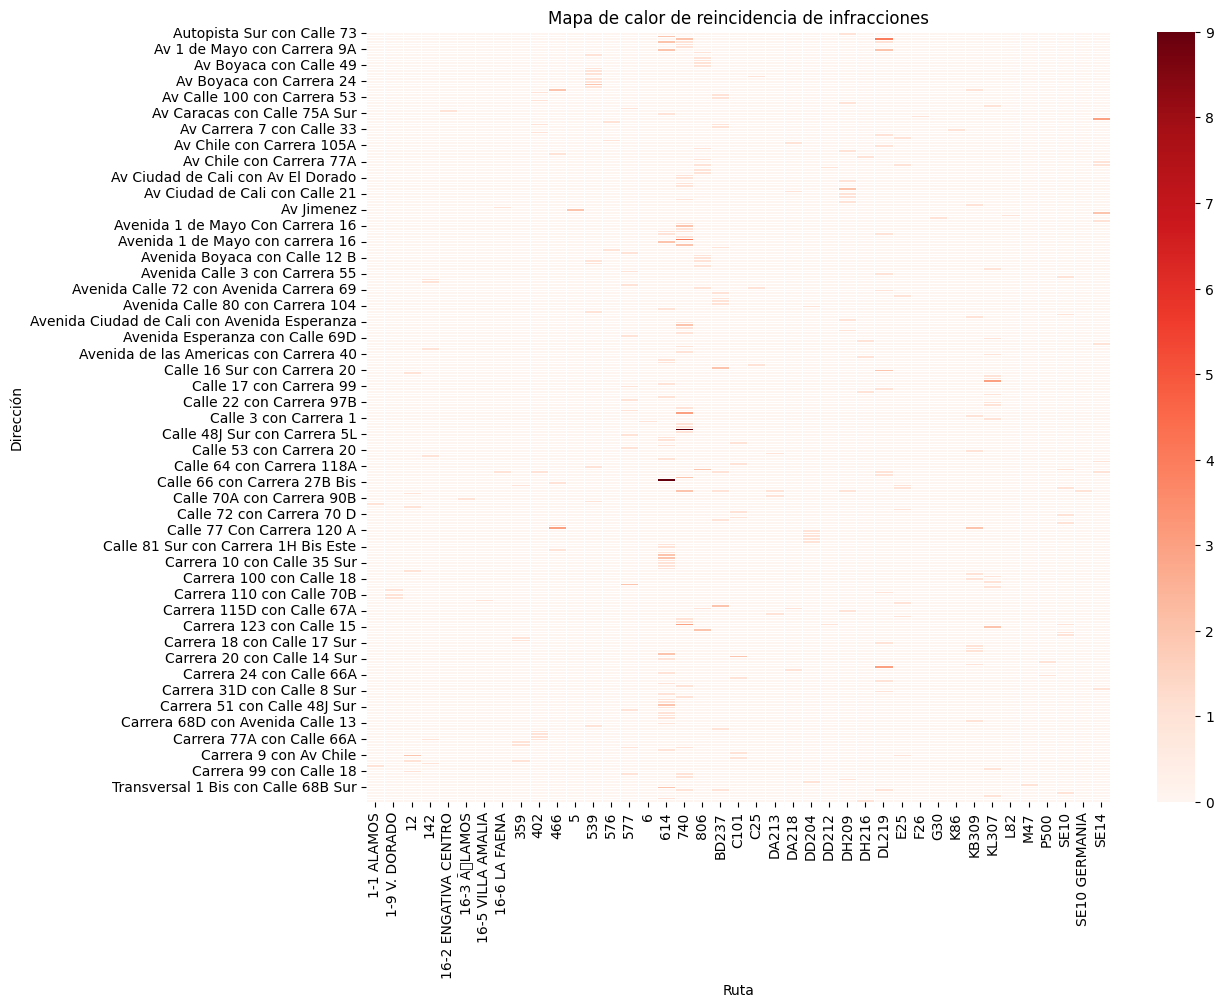

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    tabla_heat,
    cmap="Reds",
    linewidths=0.5
)

plt.title("Mapa de calor de reincidencia de infracciones")
plt.xlabel("Ruta")
plt.ylabel("Dirección")

plt.show()

In [227]:
ico_geo["intervalo_min"] = (
    ico_geo
    .groupby(["RUTA","DIRECCION_LIMPIA"])["hora_seg"]
    .diff()/60
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,11:04,11:04,11:04,11:04,1104,39840,NaN,1.0,False,0
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,10:54,10:54,10:54,10:54,1054,39240,NaN,1.0,False,0
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,14:44,14:44,14:44,14:44,1444,53040,NaN,1.0,False,0
5,7.166176e+10,1735385,50733.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510325,...,08:39,08:39,08:39,08:39,0839,31140,NaN,1.0,False,0
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0


In [228]:
intervalos = (
    ico_geo
    .groupby(["RUTA","DIRECCION_LIMPIA"])["intervalo_min"]
    .mean()
    .reset_index()
)

intervalos

,RUTA,DIRECCION_LIMPIA,intervalo_min
0,1-1 ALAMOS,Calle 72 con Carrera 105F,NaN
1,1-1 ALAMOS,Carrera 96 con Calle 75A,NaN
2,1-9 V. DORADO,Carrera 107 con Diagonal 78C,NaN
3,1-9 V. DORADO,Carrera 110 con Calle 70B,NaN
4,1-9 V. DORADO,Carrera 110 con Calle 72,NaN
...,...,...,...
317,SE14,Av Villavicencio con Carrera 22B,NaN
318,SE14,Avenida Jorge Gaitan Cortes con Calle 53B Sur,NaN
319,SE14,Calle 61 Sur con Carrera 19H,NaN
320,SE14,Calle 64 con Carrera 121,NaN


In [229]:
intervalos["prob_evento"] = 1 / intervalos["intervalo_min"]

intervalos

,RUTA,DIRECCION_LIMPIA,intervalo_min,prob_evento
0,1-1 ALAMOS,Calle 72 con Carrera 105F,NaN,NaN
1,1-1 ALAMOS,Carrera 96 con Calle 75A,NaN,NaN
2,1-9 V. DORADO,Carrera 107 con Diagonal 78C,NaN,NaN
3,1-9 V. DORADO,Carrera 110 con Calle 70B,NaN,NaN
4,1-9 V. DORADO,Carrera 110 con Calle 72,NaN,NaN
...,...,...,...,...
317,SE14,Av Villavicencio con Carrera 22B,NaN,NaN
318,SE14,Avenida Jorge Gaitan Cortes con Calle 53B Sur,NaN,NaN
319,SE14,Calle 61 Sur con Carrera 19H,NaN,NaN
320,SE14,Calle 64 con Carrera 121,NaN,NaN


Detección de puntos críticos

In [230]:
metricas = (
    ico_geo
    .groupby(["RUTA","DIRECCION_LIMPIA"])
    .agg(
        total_eventos=("COD_INFRACCION_TMSA","count"),
        intervalo_promedio=("intervalo_min","mean")
    )
    .reset_index()
)

In [231]:
metricas["indice_criticidad"] = (
    metricas["total_eventos"] /
    metricas["intervalo_promedio"]
)

metricas

,RUTA,DIRECCION_LIMPIA,total_eventos,intervalo_promedio,indice_criticidad
0,1-1 ALAMOS,Calle 72 con Carrera 105F,1,NaN,NaN
1,1-1 ALAMOS,Carrera 96 con Calle 75A,1,NaN,NaN
2,1-9 V. DORADO,Carrera 107 con Diagonal 78C,1,NaN,NaN
3,1-9 V. DORADO,Carrera 110 con Calle 70B,1,NaN,NaN
4,1-9 V. DORADO,Carrera 110 con Calle 72,1,NaN,NaN
...,...,...,...,...,...
317,SE14,Av Villavicencio con Carrera 22B,1,NaN,NaN
318,SE14,Avenida Jorge Gaitan Cortes con Calle 53B Sur,1,NaN,NaN
319,SE14,Calle 61 Sur con Carrera 19H,1,NaN,NaN
320,SE14,Calle 64 con Carrera 121,1,NaN,NaN


In [232]:
puntos_criticos = (
    metricas
    .sort_values("indice_criticidad",ascending=False)
)

puntos_criticos

,RUTA,DIRECCION_LIMPIA,total_eventos,intervalo_promedio,indice_criticidad
136,740,Avenida Ciudad de Cali con Calle 15A,2,0.0,inf
103,614,Carrera 19 con Calle 1C,2,0.0,inf
295,KL307,Carrera 123 con Calle 15,2,0.0,inf
287,KL307,Calle 17 con Carrera 120,3,0.0,inf
240,DL219,Av 1 de Mayo con Carrera 9A,2,0.0,inf
...,...,...,...,...,...
317,SE14,Av Villavicencio con Carrera 22B,1,NaN,NaN
318,SE14,Avenida Jorge Gaitan Cortes con Calle 53B Sur,1,NaN,NaN
319,SE14,Calle 61 Sur con Carrera 19H,1,NaN,NaN
320,SE14,Calle 64 con Carrera 121,1,NaN,NaN


Clusters

In [233]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: scikit-learn in c:\users\jonny villareal\appdata\local\programs\python\python312\lib\site-packages (1.5.2)




[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [234]:
coords = ico_geo[["latitud","longitud"]].dropna()

In [235]:
from sklearn.cluster import DBSCAN
import numpy as np

coords_rad = np.radians(coords)

db = DBSCAN(
    eps=0.001,      # distancia aprox ~100 m
    min_samples=5   # mínimo eventos para formar cluster
).fit(coords_rad)

ico_geo.loc[coords.index,"cluster1"] = db.labels_

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento,cluster1
0,7.166176e+10,1735372,50720.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510158,...,11:04,11:04,11:04,1104,39840,NaN,1.0,False,0,NaN
4,7.166176e+10,1735392,50738.0,Int. Operaciones,2026-01-03,3/03/2026,I8024,No aplicar manejo preventivo.,10,506530,...,10:54,10:54,10:54,1054,39240,NaN,1.0,False,0,NaN
1,7.166176e+10,1735501,50729.0,Int. Operaciones,2026-01-03,3/03/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,509187,...,14:44,14:44,14:44,1444,53040,NaN,1.0,False,0,NaN
5,7.166176e+10,1735385,50733.0,Int. Operaciones,2026-01-03,3/03/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,510325,...,08:39,08:39,08:39,0839,31140,NaN,1.0,False,0,NaN
3,7.166176e+10,1735417,50718.0,Int. Operaciones,2026-01-03,3/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,504537,...,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0,0.0


In [236]:
hotspots = (
    ico_geo[ico_geo["cluster1"] != -1]
    .groupby("cluster1")
    .size()
    .sort_values(ascending=False)
)

print(hotspots)

cluster1
0.0    88
dtype: int64


In [237]:
centros = (
    ico_geo[ico_geo["cluster1"] != -1]
    .groupby("cluster1")[["latitud","longitud"]]
    .mean()
)

centros

,latitud,longitud
cluster1,,
0.0,4.618166,-74.120185


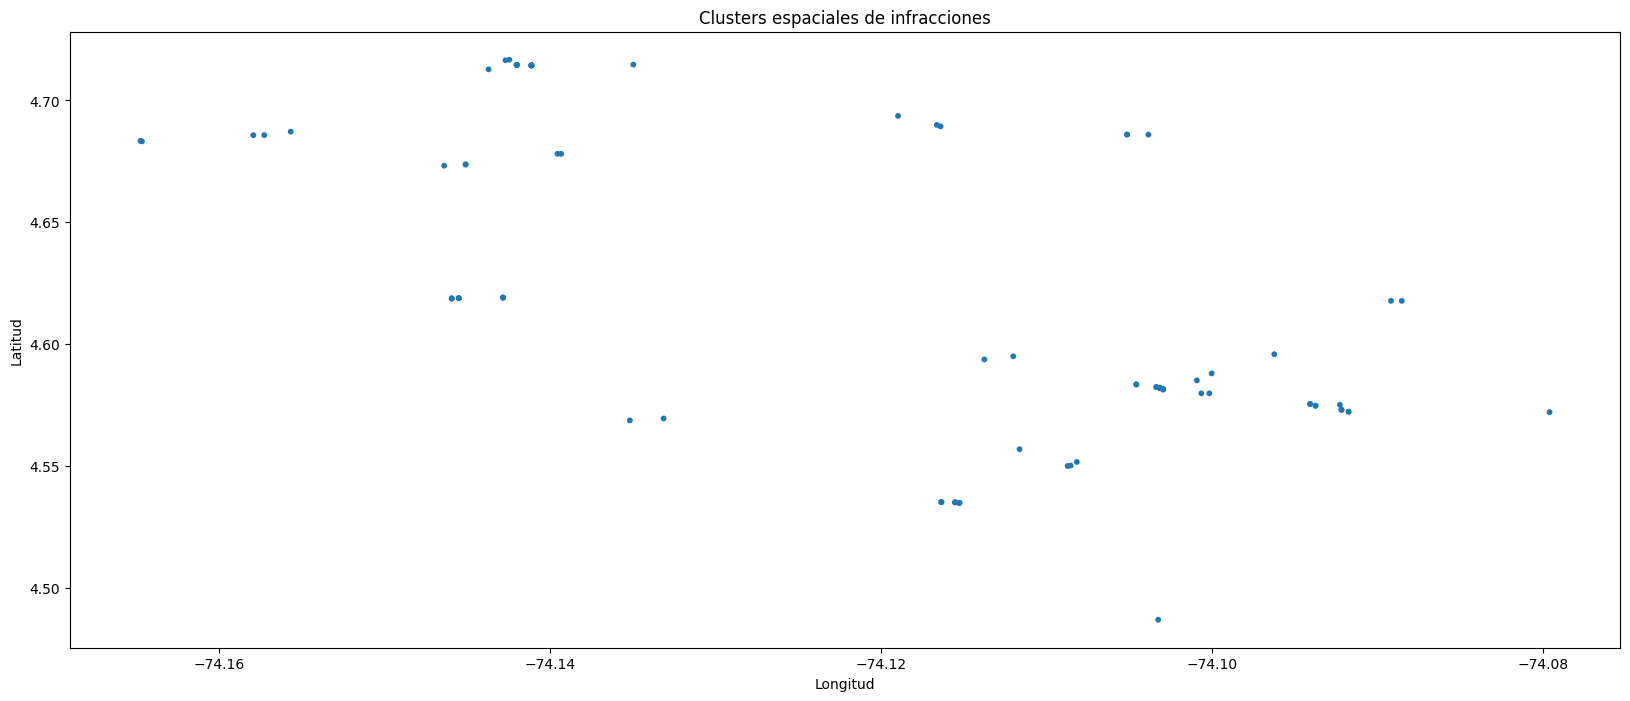

In [238]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

plt.scatter(
    ico_geo["longitud"],
    ico_geo["latitud"],
    c=ico_geo["cluster1"],
    cmap="tab10",
    s=10
)

plt.title("Clusters espaciales de infracciones")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

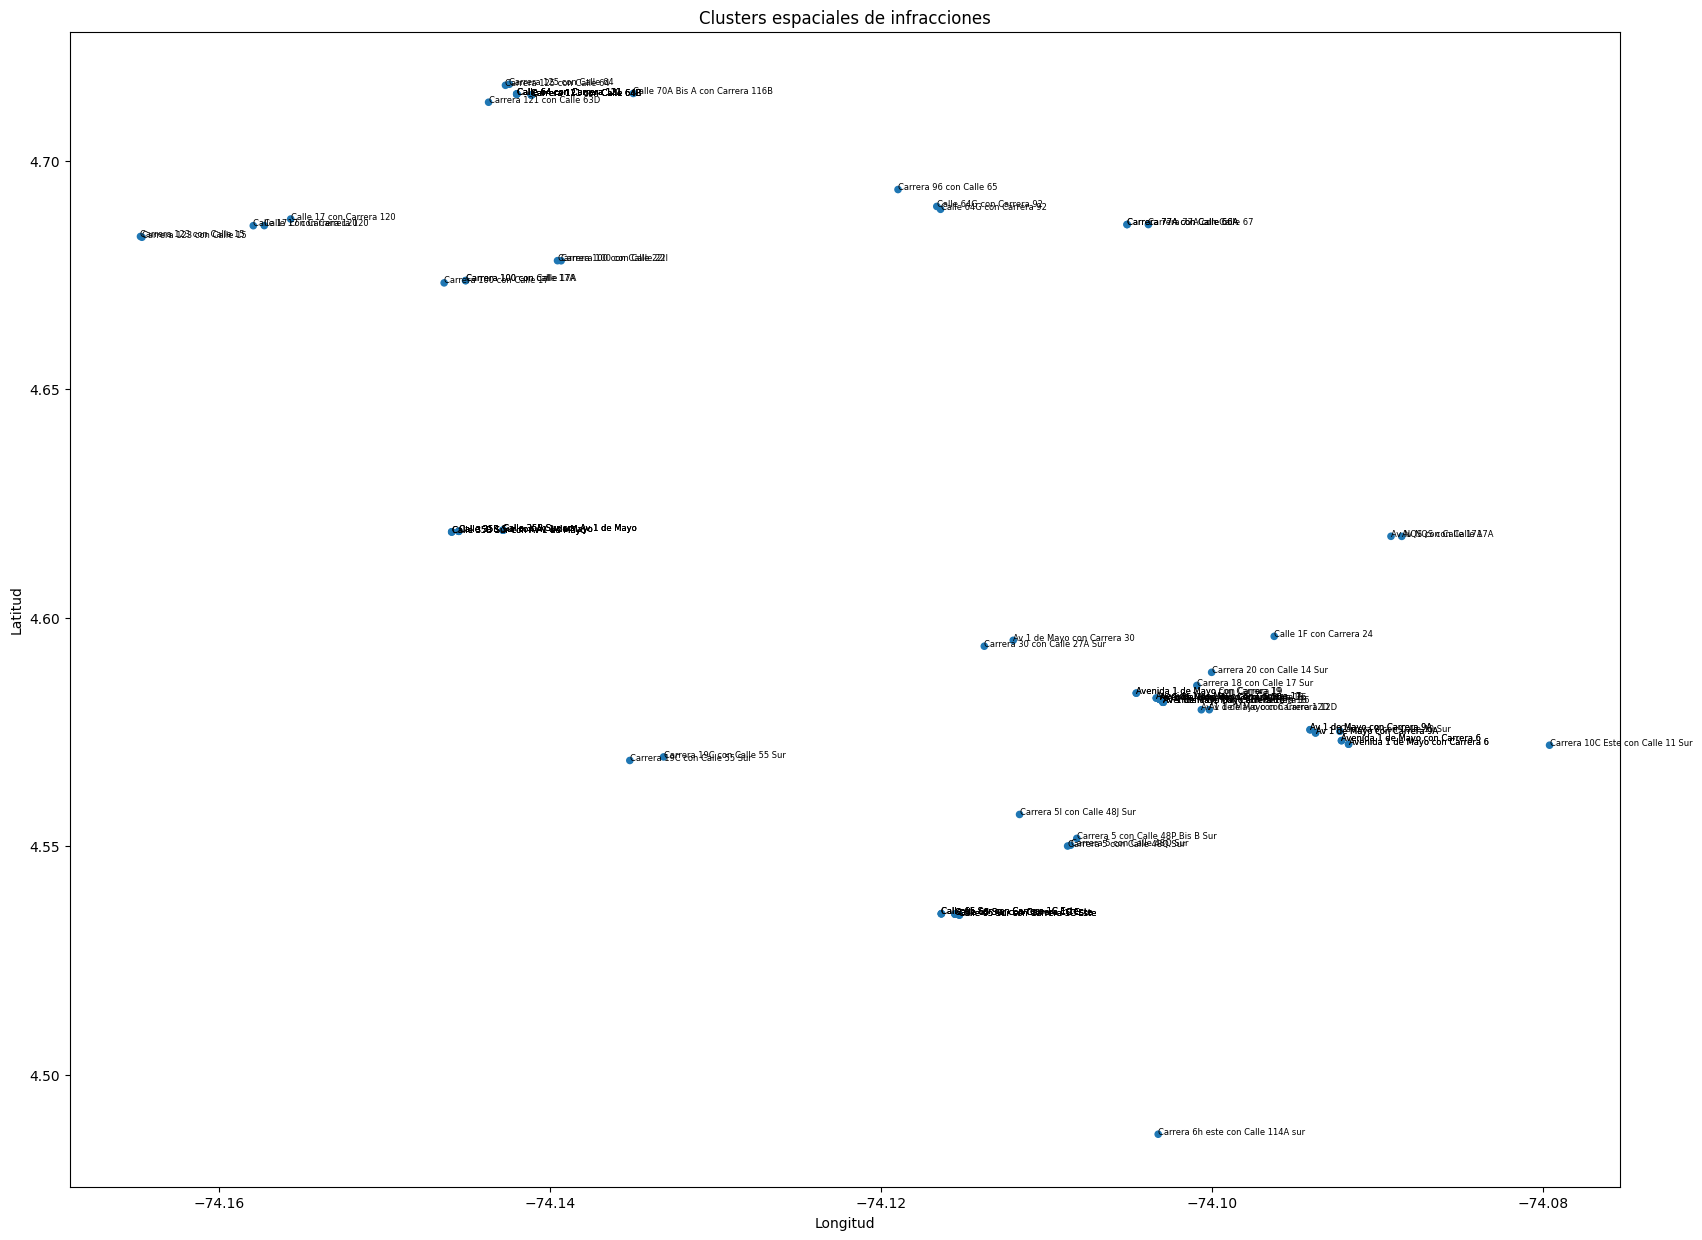

In [239]:
plt.figure(figsize=(20,15))

plt.scatter(
    ico_geo["longitud"],
    ico_geo["latitud"],
    c=ico_geo["cluster1"],
    cmap="tab10",
    s=20
)

for i, row in ico_geo.iterrows():
    plt.text(
        row["longitud"],
        row["latitud"],
        row["DIRECCION_LIMPIA"],
        fontsize=6
    )

plt.title("Clusters espaciales de infracciones")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

In [240]:
hotspots_dir = (
    ico_geo[ico_geo["cluster1"] != -1]
    .groupby(["cluster1","DIRECCION_LIMPIA"])
    .size()
    .reset_index(name="eventos")
    .sort_values(["cluster1","eventos"],ascending=False)
)

hotspots_dir.head(20)

,cluster1,DIRECCION_LIMPIA,eventos
13,0.0,Calle 35B Sur con Av 1 de Mayo,9
16,0.0,Calle 65 Sur con Carrera 1C Este,9
1,0.0,Av 1 de Mayo con Carrera 16,6
14,0.0,Calle 64 con Carrera 121,5
24,0.0,Carrera 121 con Calle 64B,5
3,0.0,Av 1 de Mayo con Carrera 9A,4
9,0.0,Avenida 1 de Mayo con Carrera 6,4
11,0.0,Calle 17 con Carrera 120,3
0,0.0,Av 1 de Mayo con Carrera 12D,2
4,0.0,Av NQS con Calle 17A,2


In [241]:
print(ico_geo.groupby(["cluster1","COD_INFRACCION_TMSA"]).size())

cluster1  COD_INFRACCION_TMSA
0.0       I5023-3                37
          I6003-1                 1
          I6012                   7
          I6017-1                 1
          I6019                   7
          I6019-1                 1
          I6020-1                 1
          I6024                  16
          I6025                   3
          I6029                   3
          I6035                   2
          I8007                   1
          I8007-1                 3
          I8024                   5
dtype: int64


In [242]:
print(ico_geo.groupby(["cluster1","RUTA"]).size())

cluster1  RUTA         
0.0       142               2
          16-6 LA FAENA     1
          359               1
          402               2
          539               1
          577               2
          614              23
          740              26
          806               2
          BD237             1
          C101              2
          DA213             1
          DD212             1
          DL219            10
          KB309             1
          KL307             7
          SE10              1
          SE14              4
dtype: int64


In [243]:
ico_geo = ico_geo.sort_values([
    "COD_OPERADOR",
    "RUTA",
    "DIRECCION_LIMPIA",
    "COD_INFRACCION_TMSA",
    "FECHA__IDENTIFICACION_",
    "hora_seg"
])

In [244]:
ico_geo["intervalo_operador"] = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "RUTA",
        "DIRECCION_LIMPIA",
        "COD_INFRACCION_TMSA"
    ])["hora_seg"]
    .diff() / 60
)

In [245]:
ico_geo["repeticion_operador"] = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "RUTA",
        "DIRECCION_LIMPIA",
        "COD_INFRACCION_TMSA",
        "FECHA__IDENTIFICACION_"
    ])
    .cumcount() + 1
)

ico_geo

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,21:23,2123,76980,NaN,NaN,False,0,NaN,NaN,NaN
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,07:49,0749,28140,25.0,1.0,False,0,NaN,NaN,1.0
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,07:50,0750,28200,NaN,1.0,False,0,NaN,NaN,1.0
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,07:18,0718,26280,NaN,1.0,False,0,NaN,NaN,1.0
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,07:24,0724,26640,NaN,1.0,False,0,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,7.166176e+10,1751295,55724.0,Int. Operaciones,NaT,27/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,510482,...,14:58,1458,53880,NaN,NaN,False,0,NaN,NaN,NaN
362,7.166176e+10,1751332,55624.0,Int. Operaciones,NaT,27/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,510483,...,14:10,1410,51000,NaN,NaN,False,0,NaN,NaN,NaN
286,7.166176e+10,1747741,54476.0,Int. Operaciones,NaT,24/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,510488,...,11:23,1123,40980,NaN,NaN,False,0,NaN,NaN,NaN
392,7.166176e+10,1754252,56692.0,Int. Operaciones,NaT,6/04/2026,I6029,Conducir peligrosamente o bruscamente el vehÃ­...,15,510488,...,07:16,0716,26160,NaN,NaN,False,0,NaN,NaN,NaN


In [246]:
ico_geo["evento_seguido_operador"] = (
    ico_geo["intervalo_operador"] <= 10
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,2123,76980,NaN,NaN,False,0,NaN,NaN,NaN,False
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,0749,28140,25.0,1.0,False,0,NaN,NaN,1.0,False
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,0750,28200,NaN,1.0,False,0,NaN,NaN,1.0,False
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,0718,26280,NaN,1.0,False,0,NaN,NaN,1.0,False
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,0724,26640,NaN,1.0,False,0,NaN,NaN,1.0,False


In [247]:
infracciones_operador = (
    ico_geo
    .groupby("COD_OPERADOR")
    .size()
    .sort_values(ascending=False)
)

print(infracciones_operador.head())

COD_OPERADOR
508377    6
510162    6
509475    4
510245    4
510206    4
dtype: int64


In [248]:
infracciones_ruta = (
    ico_geo
    .groupby(["COD_OPERADOR","RUTA"])
    .size()
    .reset_index(name="cantidad")
)

infracciones_ruta.head()

,COD_OPERADOR,RUTA,cantidad
0,500031,M47,1
1,500166,5,1
2,500428,539,2
3,500701,5,1
4,500716,614,1


In [249]:
infracciones_direccion = (
    ico_geo
    .groupby(["COD_OPERADOR","DIRECCION_LIMPIA"])
    .size()
    .reset_index(name="cantidad")
)

infracciones_direccion

,COD_OPERADOR,DIRECCION_LIMPIA,cantidad
0,500031,NQS - Calle 38A Sur B - 4 o 6,1
1,500166,Av Jimenez,1
2,500428,Av Boyaca con Calle 11D,1
3,500428,Av Boyaca con Calle 7C Bis,1
4,500701,Av Jimenez,1
...,...,...,...
342,510482,Calle 77 con Transversal 123 A,1
343,510483,Av Ciudad de Cali con Diagonal 25G,1
344,510488,Avenida Agoberto Mejia con Diagonal 2,1
345,510488,Calle 72 con Carrera 70 D,1


In [250]:
tipo_infraccion = (
    ico_geo
    .groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])
    .size()
    .reset_index(name="cantidad")
)

tipo_infraccion

,COD_OPERADOR,COD_INFRACCION_TMSA,cantidad
0,500031,M1002,1
1,500166,M0021,1
2,500428,I5023-3,1
3,500428,I6012,1
4,500701,M0021,1
...,...,...,...
339,510482,I5023-3,1
340,510483,I5023-3,1
341,510488,I5023-3,1
342,510488,I6029,1


In [251]:
intervalo_promedio = (
    ico_geo
    .groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])
    ["intervalo_operador"]
    .mean()
    .reset_index()
)

intervalo_promedio

,COD_OPERADOR,COD_INFRACCION_TMSA,intervalo_operador
0,500031,M1002,NaN
1,500166,M0021,NaN
2,500428,I5023-3,NaN
3,500428,I6012,NaN
4,500701,M0021,NaN
...,...,...,...
339,510482,I5023-3,NaN
340,510483,I5023-3,NaN
341,510488,I5023-3,NaN
342,510488,I6029,NaN


In [252]:
metricas_operador = (
    ico_geo
    .groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])
    .agg(
        total_eventos=("COD_INFRACCION_TMSA","count"),
        intervalo_promedio=("intervalo_operador","mean")
    )
    .reset_index()
)

metricas_operador["indice_reincidencia"] = (
    metricas_operador["total_eventos"] /
    metricas_operador["intervalo_promedio"]
)

metricas_operador

,COD_OPERADOR,COD_INFRACCION_TMSA,total_eventos,intervalo_promedio,indice_reincidencia
0,500031,M1002,1,NaN,NaN
1,500166,M0021,1,NaN,NaN
2,500428,I5023-3,1,NaN,NaN
3,500428,I6012,1,NaN,NaN
4,500701,M0021,1,NaN,NaN
...,...,...,...,...,...
339,510482,I5023-3,1,NaN,NaN
340,510483,I5023-3,1,NaN,NaN
341,510488,I5023-3,1,NaN,NaN
342,510488,I6029,1,NaN,NaN


In [253]:
ico_geo["hora_hhmm"] = (
    ico_geo["hora_hhmm"]
    .astype(str)
    .str.replace("::", ":", regex=False)   # corrige 07::10
    .str.strip()
)

In [254]:
ico_geo["hora_dt"] = pd.to_datetime(
    ico_geo["hora_hhmm"],
    format="mixed",
    errors="coerce"
)

In [255]:
def clasificar_franja(hora):

    if pd.isna(hora):
        return None

    h = hora.hour

    if 0 <= h < 6:
        return "Madrugada"
    elif 6 <= h < 10:
        return "AM Pico"
    elif 10 <= h < 13:
        return "Valle Mañana"
    elif 13 <= h < 16:
        return "Valle Tarde"
    elif 16 <= h < 20:
        return "PM Pico"
    else:
        return "Noche"

ico_geo["Franja"] = ico_geo["hora_dt"].apply(clasificar_franja)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,intervalo_min,repeticion_evento,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador,hora_dt,Franja
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,NaN,False,0,NaN,NaN,NaN,False,2026-05-13 21:23:00,Noche
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,25.0,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:49:00,AM Pico
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,NaN,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:50:00,AM Pico
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,NaN,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:18:00,AM Pico
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,NaN,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:24:00,AM Pico


In [256]:
patrones = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "FECHA__IDENTIFICACION_",
        "COD_INFRACCION_TMSA",
        "DESCRIPCION",
        "DIRECCION_LIMPIA",
        "Franja"
    ])
    .size()
    .reset_index(name="Cantidad")
)

patrones

,COD_OPERADOR,FECHA__IDENTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,DIRECCION_LIMPIA,Franja,Cantidad
0,500166,2026-05-03,M0021,No cumplir con los lineamientos u obligaciones...,Av Jimenez,AM Pico,1
1,500428,2026-06-03,I5023-3,No cumplir con los lineamientos establecidos e...,Av Boyaca con Calle 7C Bis,AM Pico,1
2,500428,2026-06-03,I6012,"Manipular, tener a la mano o usar equipos elec...",Av Boyaca con Calle 11D,AM Pico,1
3,500701,2026-04-03,M0021,No cumplir con los lineamientos u obligaciones...,Av Jimenez,AM Pico,1
4,500716,2026-12-03,I6024,Pasar el semÃ¡foro en rojo.,Transversal 1 Bis con Calle 68B Sur,AM Pico,1
...,...,...,...,...,...,...,...
162,510421,2026-05-03,I6019-2,Omitir o realizar de forma indebida el PARE,Carrera 24 con Calle 13 Sur,PM Pico,1
163,510433,2026-02-03,I6003-1,No cumplir con las paradas establecidas en el ...,Avenida Calle 53 con Carrera 74A,Noche,1
164,510447,2026-10-03,I6035,Manejo peligroso con otro vehÃ­culo del Sistem...,Diagonal 63F con Carrera 89A,PM Pico,1
165,510452,2026-10-03,I6012,"Manipular, tener a la mano o usar equipos elec...",Carrera 117 con Calle 63H,PM Pico,1


In [257]:
reincidentes = patrones[patrones["Cantidad"] > 1]

reincidentes.head()

,COD_OPERADOR,FECHA__IDENTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,DIRECCION_LIMPIA,Franja,Cantidad
6,501243,2026-10-03,I5023-3,No cumplir con los lineamientos establecidos e...,Avenida 1 de Mayo con Carrera 6,Valle Tarde,2
43,507845,2026-11-03,I8007-1,Transitar con el rutero sin la con la configur...,Avenida 1 de Mayo con carrera 16,PM Pico,2
49,508377,2026-03-03,I5023-3,No cumplir con los lineamientos establecidos e...,Calle 65 Sur con Carrera 1C Este,PM Pico,3
50,508377,2026-04-03,I5023-3,No cumplir con los lineamientos establecidos e...,Calle 65 Sur con Carrera 1C Este,PM Pico,3
54,508505,2026-02-03,I5023-3,No cumplir con los lineamientos establecidos e...,Av 1 de Mayo con Carrera 16,PM Pico,2


In [258]:
operador_patrones = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "COD_INFRACCION_TMSA",
        "DESCRIPCION",
        "DIRECCION_LIMPIA",
        "Franja"
    ])
    .size()
    .reset_index(name="Total")
    .sort_values("Total", ascending=False)
)

operador_patrones.head()

,COD_OPERADOR,COD_INFRACCION_TMSA,DESCRIPCION,DIRECCION_LIMPIA,Franja,Total
260,510162,I6024,Pasar el semÃ¡foro en rojo.,Calle 35B Sur con Av 1 de Mayo,AM Pico,6
100,508377,I5023-3,No cumplir con los lineamientos establecidos e...,Calle 65 Sur con Carrera 1C Este,PM Pico,6
154,509289,I5023-3,No cumplir con los lineamientos establecidos e...,Calle 17 con Carrera 120,Valle Mañana,3
219,509895,I6029,Conducir peligrosamente o bruscamente el vehÃ­...,Calle 65 Sur con Carrera 1C Este,AM Pico,3
286,510277,I6024,Pasar el semÃ¡foro en rojo.,Calle 35B Sur con Av 1 de Mayo,AM Pico,3


In [259]:
ico_geo = ico_geo.sort_values([
    "COD_OPERADOR",
    "COD_INFRACCION_TMSA",
    "DESCRIPCION",
    "DIRECCION_LIMPIA",
    "FECHA__IDENTIFICACION_",
    "hora_seg"
])

In [260]:
ico_geo["intervalo_infraccion"] = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "COD_INFRACCION_TMSA",
        "DIRECCION_LIMPIA"
    ])["hora_seg"]
    .diff()
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,repeticion_evento,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador,hora_dt,Franja,intervalo_infraccion
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,False,0,NaN,NaN,NaN,False,2026-05-13 21:23:00,Noche,NaN
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:49:00,AM Pico,NaN
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:18:00,AM Pico,NaN
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:50:00,AM Pico,NaN
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:24:00,AM Pico,NaN


In [261]:
patron_dominante = (
    operador_patrones
    .groupby("COD_OPERADOR")
    .first()
    .reset_index()
)

patron_dominante

,COD_OPERADOR,COD_INFRACCION_TMSA,DESCRIPCION,DIRECCION_LIMPIA,Franja,Total
0,500031,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,NQS - Calle 38A Sur B - 4 o 6,Noche,1
1,500166,M0021,No cumplir con los lineamientos u obligaciones...,Av Jimenez,AM Pico,1
2,500428,I6012,"Manipular, tener a la mano o usar equipos elec...",Av Boyaca con Calle 11D,AM Pico,1
3,500701,M0021,No cumplir con los lineamientos u obligaciones...,Av Jimenez,AM Pico,1
4,500716,I6024,Pasar el semÃ¡foro en rojo.,Transversal 1 Bis con Calle 68B Sur,AM Pico,1
...,...,...,...,...,...,...
289,510472,I8024,No aplicar manejo preventivo.,Calle 68 con Carrera 65,Valle Mañana,1
290,510482,I5023-3,No cumplir con los lineamientos establecidos e...,Calle 77 con Transversal 123 A,Valle Tarde,1
291,510483,I5023-3,No cumplir con los lineamientos establecidos e...,Av Ciudad de Cali con Diagonal 25G,Valle Tarde,1
292,510488,I6029,Conducir peligrosamente o bruscamente el vehÃ­...,Calle 72 con Carrera 70 D,AM Pico,1


In [262]:
tabla = (
    ico_geo
    .groupby(["COD_OPERADOR","Franja"])
    .size()
    .unstack(fill_value=0)
)

tabla

Franja,AM Pico,Madrugada,Noche,PM Pico,Valle Mañana,Valle Tarde
COD_OPERADOR,,,,,,
500031,0,0,1,0,0,0
500166,1,0,0,0,0,0
500428,2,0,0,0,0,0
500701,1,0,0,0,0,0
500716,1,0,0,0,0,0
...,...,...,...,...,...,...
510472,0,0,0,0,1,0
510482,0,0,0,0,0,1
510483,0,0,0,0,0,1


In [263]:
total_operador = (
    ico_geo
    .groupby("COD_OPERADOR")
    .size()
    .reset_index(name="total_infracciones")
)

total_operador

,COD_OPERADOR,total_infracciones
0,500031,1
1,500166,1
2,500428,2
3,500701,1
4,500716,1
...,...,...
292,510472,1
293,510482,1
294,510483,1
295,510488,2


In [264]:
repeticiones = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "FECHA__IDENTIFICACION_",
        "COD_INFRACCION_TMSA",
        "DIRECCION_LIMPIA",
        "Franja"
    ])
    .size()
    .reset_index(name="conteo")
)

repeticiones 

,COD_OPERADOR,FECHA__IDENTIFICACION_,COD_INFRACCION_TMSA,DIRECCION_LIMPIA,Franja,conteo
0,500166,2026-05-03,M0021,Av Jimenez,AM Pico,1
1,500428,2026-06-03,I5023-3,Av Boyaca con Calle 7C Bis,AM Pico,1
2,500428,2026-06-03,I6012,Av Boyaca con Calle 11D,AM Pico,1
3,500701,2026-04-03,M0021,Av Jimenez,AM Pico,1
4,500716,2026-12-03,I6024,Transversal 1 Bis con Calle 68B Sur,AM Pico,1
...,...,...,...,...,...,...
162,510421,2026-05-03,I6019-2,Carrera 24 con Calle 13 Sur,PM Pico,1
163,510433,2026-02-03,I6003-1,Avenida Calle 53 con Carrera 74A,Noche,1
164,510447,2026-10-03,I6035,Diagonal 63F con Carrera 89A,PM Pico,1
165,510452,2026-10-03,I6012,Carrera 117 con Calle 63H,PM Pico,1


In [265]:
repeticiones_reales = repeticiones[repeticiones["conteo"] > 1]

In [266]:
rep_operador = (
    repeticiones_reales
    .groupby("COD_OPERADOR")["conteo"]
    .sum()
    .reset_index(name="infracciones_repetidas")
)

rep_operador

,COD_OPERADOR,infracciones_repetidas
0,501243,2
1,507845,2
2,508377,6
3,508505,2
4,508844,2
5,509289,3
6,509328,2
7,509658,2
8,509770,2
9,509895,3


In [267]:
indice_reincidencia = total_operador.merge(
    rep_operador,
    on="COD_OPERADOR",
    how="left"
)

indice_reincidencia["infracciones_repetidas"] = (
    indice_reincidencia["infracciones_repetidas"].fillna(0)
)

indice_reincidencia["indice_reincidencia"] = (
    indice_reincidencia["infracciones_repetidas"] /
    indice_reincidencia["total_infracciones"]
)

indice_reincidencia.head()

,COD_OPERADOR,total_infracciones,infracciones_repetidas,indice_reincidencia
0,500031,1,0.0,0.0
1,500166,1,0.0,0.0
2,500428,2,0.0,0.0
3,500701,1,0.0,0.0
4,500716,1,0.0,0.0


In [268]:
def clasificar_indice(x):

    if x < 0.10:
        return "🟢 Normal"

    elif x < 0.30:
        return "🟡 Reincidencia moderada"

    else:
        return "🔴 Reincidencia crítica"

indice_reincidencia["clasificacion"] = (
    indice_reincidencia["indice_reincidencia"]
    .apply(clasificar_indice)
)

indice_reincidencia.head()

,COD_OPERADOR,total_infracciones,infracciones_repetidas,indice_reincidencia,clasificacion
0,500031,1,0.0,0.0,🟢 Normal
1,500166,1,0.0,0.0,🟢 Normal
2,500428,2,0.0,0.0,🟢 Normal
3,500701,1,0.0,0.0,🟢 Normal
4,500716,1,0.0,0.0,🟢 Normal


In [269]:
indice_reincidencia.sort_values(
    "indice_reincidencia",
    ascending=False
)

,COD_OPERADOR,total_infracciones,infracciones_repetidas,indice_reincidencia,clasificacion
188,509895,3,3.0,1.0,🔴 Reincidencia crítica
88,508377,6,6.0,1.0,🔴 Reincidencia crítica
192,509937,2,2.0,1.0,🔴 Reincidencia crítica
246,510277,3,3.0,1.0,🔴 Reincidencia crítica
176,509770,2,2.0,1.0,🔴 Reincidencia crítica
...,...,...,...,...,...
100,508600,2,0.0,0.0,🟢 Normal
99,508598,1,0.0,0.0,🟢 Normal
98,508564,1,0.0,0.0,🟢 Normal
97,508548,1,0.0,0.0,🟢 Normal


In [270]:
total_operador = (
    ico_geo
    .groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])
    .size()
    .reset_index(name="total_infracciones")
)

In [271]:
repeticiones = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "COD_INFRACCION_TMSA",
        "FECHA__IDENTIFICACION_",
        "DIRECCION_LIMPIA",
        "Franja"
    ])
    .size()
    .reset_index(name="conteo")
)

In [272]:
repeticiones_reales = repeticiones[repeticiones["conteo"] > 1]

In [273]:
rep_operador = (
    repeticiones_reales
    .groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])["conteo"]
    .sum()
    .reset_index(name="infracciones_repetidas")
)

In [274]:
indice_reincidencia = total_operador.merge(
    rep_operador,
    on=["COD_OPERADOR","COD_INFRACCION_TMSA"],
    how="left"
)

indice_reincidencia["infracciones_repetidas"] = (
    indice_reincidencia["infracciones_repetidas"].fillna(0)
)

indice_reincidencia["indice_reincidencia"] = (
    indice_reincidencia["infracciones_repetidas"] /
    indice_reincidencia["total_infracciones"]
)

In [275]:
def clasificar_indice(x):

    if x < 0.10:
        return "🟢 Normal"
    elif x < 0.30:
        return "🟡 Reincidencia moderada"
    else:
        return "🔴 Reincidencia crítica"

indice_reincidencia["clasificacion"] = (
    indice_reincidencia["indice_reincidencia"]
    .apply(clasificar_indice)
)

indice_reincidencia.head()

,COD_OPERADOR,COD_INFRACCION_TMSA,total_infracciones,infracciones_repetidas,indice_reincidencia,clasificacion
0,500031,M1002,1,0.0,0.0,🟢 Normal
1,500166,M0021,1,0.0,0.0,🟢 Normal
2,500428,I5023-3,1,0.0,0.0,🟢 Normal
3,500428,I6012,1,0.0,0.0,🟢 Normal
4,500701,M0021,1,0.0,0.0,🟢 Normal


In [276]:
indice_reincidencia.sort_values(
    "indice_reincidencia",
    ascending=False
)

,COD_OPERADOR,COD_INFRACCION_TMSA,total_infracciones,infracciones_repetidas,indice_reincidencia,clasificacion
152,509289,I5023-3,3,3.0,1.0,🔴 Reincidencia crítica
267,510206,I6035,2,2.0,1.0,🔴 Reincidencia crítica
256,510162,I6024,6,6.0,1.0,🔴 Reincidencia crítica
215,509895,I6029,3,3.0,1.0,🔴 Reincidencia crítica
280,510277,I6024,3,3.0,1.0,🔴 Reincidencia crítica
...,...,...,...,...,...,...
115,508600,I8024,1,0.0,0.0,🟢 Normal
114,508600,I6011,1,0.0,0.0,🟢 Normal
113,508598,I6012,1,0.0,0.0,🟢 Normal
112,508564,I8024,1,0.0,0.0,🟢 Normal


In [277]:
ico_puntos = ico_geo.copy()

ico_puntos.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,repeticion_evento,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador,hora_dt,Franja,intervalo_infraccion
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,False,0,NaN,NaN,NaN,False,2026-05-13 21:23:00,Noche,NaN
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:49:00,AM Pico,NaN
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:18:00,AM Pico,NaN
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:50:00,AM Pico,NaN
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:24:00,AM Pico,NaN


In [278]:
# Convertir la columna 'Fecha' al formato de fecha y luego formatearla como 'dd/MM/yyyy' en tipo día
ico_puntos['FECHA__IDENT'] = pd.to_datetime(ico_puntos['FECHA__IDENT'], format='%d/%m/%Y', errors='coerce')

# Formatear la fecha para que siempre tenga dos dígitos en día y mes
ico_puntos['FECHA__IDENT'] = ico_puntos['FECHA__IDENT'].dt.strftime('%d/%m/%Y')

# Verificar el resultado
ico_puntos.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,repeticion_evento,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador,hora_dt,Franja,intervalo_infraccion
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,False,0,NaN,NaN,NaN,False,2026-05-13 21:23:00,Noche,NaN
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:49:00,AM Pico,NaN
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:18:00,AM Pico,NaN
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:50:00,AM Pico,NaN
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,1.0,False,0,NaN,NaN,1.0,False,2026-05-13 07:24:00,AM Pico,NaN


In [279]:
#Llevar tipo día a iri

def calcular_posicion(fecha):
    
    filtro = (
        (tipo_dia['Fecha'] == fecha)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not tipo_dia.loc[filtro].empty:
        # Obtener el primer valor
        Tipo_día = tipo_dia.loc[filtro, 'Tipo Día'].iloc[0]
        return Tipo_día  if not pd.isna(Tipo_día ) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
ico_puntos['Tipo dia'] = ico_puntos.apply(
    lambda row: calcular_posicion(
        row['FECHA__IDENT']
    ),
    axis=1
)

ico_puntos.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador,hora_dt,Franja,intervalo_infraccion,Tipo dia
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,False,0,NaN,NaN,NaN,False,2026-05-13 21:23:00,Noche,NaN,Hábil
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,False,0,NaN,NaN,1.0,False,2026-05-13 07:49:00,AM Pico,NaN,Hábil
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,False,0,NaN,NaN,1.0,False,2026-05-13 07:18:00,AM Pico,NaN,Hábil
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,False,0,NaN,NaN,1.0,False,2026-05-13 07:50:00,AM Pico,NaN,Hábil
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,False,0,NaN,NaN,1.0,False,2026-05-13 07:24:00,AM Pico,NaN,Hábil


In [280]:
# Función para obtener la letra inicial de cada palabra
def obtener_letra_inicial(texto):
    palabras = texto.split()
    iniciales = [palabra[0] for palabra in palabras]
    return ''.join(iniciales)

# Aplicar la función a la columna 'Tipo día'
ico_puntos['Tipo_dia'] = ico_puntos['Tipo dia'].apply(obtener_letra_inicial)

ico_puntos.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,cluster_evento,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador,hora_dt,Franja,intervalo_infraccion,Tipo dia,Tipo_dia
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,0,NaN,NaN,NaN,False,2026-05-13 21:23:00,Noche,NaN,Hábil,H
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,0,NaN,NaN,1.0,False,2026-05-13 07:49:00,AM Pico,NaN,Hábil,H
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,0,NaN,NaN,1.0,False,2026-05-13 07:18:00,AM Pico,NaN,Hábil,H
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,0,NaN,NaN,1.0,False,2026-05-13 07:50:00,AM Pico,NaN,Hábil,H
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,0,NaN,NaN,1.0,False,2026-05-13 07:24:00,AM Pico,NaN,Hábil,H


In [281]:
ico_puntos['franja'] = (
    ico_puntos['hora_hhmm']
    .astype(str)
    .str.split(':')
    .str[0]
    .astype(int)
)

ico_puntos.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador,hora_dt,Franja,intervalo_infraccion,Tipo dia,Tipo_dia,franja
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,NaN,NaN,False,2026-05-13 21:23:00,Noche,NaN,Hábil,H,21
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,NaN,NaN,1.0,False,2026-05-13 07:49:00,AM Pico,NaN,Hábil,H,7
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,NaN,NaN,1.0,False,2026-05-13 07:18:00,AM Pico,NaN,Hábil,H,7
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,NaN,NaN,1.0,False,2026-05-13 07:50:00,AM Pico,NaN,Hábil,H,7
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,NaN,NaN,1.0,False,2026-05-13 07:24:00,AM Pico,NaN,Hábil,H,7


In [282]:
# Convertir las columnas de fecha en ambos DataFrames a datetime
ico_puntos['FECHA__IDENT'] = pd.to_datetime(ico_puntos['FECHA__IDENT'], dayfirst=True)  # Ajusta el formato según sea necesario
df_final['Fecha'] = pd.to_datetime(df_final['Fecha'], dayfirst=True)

def calcular_conductor(fecha, numeroBus, horaReferencia, ventana=600):
    hora_ref = int(horaReferencia)

    # Filtrar por fecha y bus
    filtro = (
        (df_final['Fecha'] == fecha) &
        (df_final['Código Bus'] == numeroBus)
    )
    
    resultados = df_final.loc[filtro].copy()
    
    if not resultados.empty:
        # Calcular diferencia
        resultados['diferencia'] = abs(resultados['Horas_Minutos_Segundos'] - hora_ref)
        
        # 🔥 FILTRO CLAVE: solo dentro de la ventana
        resultados = resultados[resultados['diferencia'] <= ventana]
        
        if not resultados.empty:
            # Tomar el más cercano dentro de la ventana
            resultado = resultados.sort_values(by='diferencia').iloc[0]
            return resultado['Id Línea'] if not pd.isna(resultado['Id Línea']) else None

    return None

# Aplicar la función a acada fila en quejas
ico_puntos['Id Línea'] = ico_puntos.apply(
    lambda row: calcular_conductor(
        row['FECHA__IDENT'],
        row['MOVIL'],
        row['hora_seg'],
        ventana=600
    ),
    axis=1
)

# Rellenar valores NaN y convertir a entero
ico_puntos['Id Línea'].fillna(0, inplace=True)
ico_puntos['Id Línea'] = ico_puntos['Id Línea'].astype(int)

# Mostrar el DataFrame actualizado
ico_puntos.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_15900\1031420809.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ico_puntos['Id Línea'].fillna(0, inplace=True)


,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,intervalo_operador,repeticion_operador,evento_seguido_operador,hora_dt,Franja,intervalo_infraccion,Tipo dia,Tipo_dia,franja,Id Línea
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,NaN,False,2026-05-13 21:23:00,Noche,NaN,Hábil,H,21,0
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,NaN,1.0,False,2026-05-13 07:49:00,AM Pico,NaN,Hábil,H,7,0
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,NaN,1.0,False,2026-05-13 07:18:00,AM Pico,NaN,Hábil,H,7,10194
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,NaN,1.0,False,2026-05-13 07:50:00,AM Pico,NaN,Hábil,H,7,10194
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,NaN,1.0,False,2026-05-13 07:24:00,AM Pico,NaN,Hábil,H,7,0


In [283]:
# Convertir las columnas de fecha en ambos DataFrames a datetime
ico_puntos['FECHA__IDENT'] = pd.to_datetime(ico_puntos['FECHA__IDENT'], dayfirst=True)  # Ajusta el formato según sea necesario
df_final['Fecha'] = pd.to_datetime(df_final['Fecha'], dayfirst=True)

def calcular_conductor(fecha, numeroBus, horaReferencia, ventana=600):
    hora_ref = int(horaReferencia)

    # Filtrar por fecha y bus
    filtro = (
        (df_final['Fecha'] == fecha) &
        (df_final['Código Bus'] == numeroBus)
    )
    
    resultados = df_final.loc[filtro].copy()
    
    if not resultados.empty:
        # Calcular diferencia
        resultados['diferencia'] = abs(resultados['Horas_Minutos_Segundos'] - hora_ref)
        
        # 🔥 FILTRO CLAVE: solo dentro de la ventana
        resultados = resultados[resultados['diferencia'] <= ventana]
        
        if not resultados.empty:
            # Tomar el más cercano dentro de la ventana
            resultado = resultados.sort_values(by='diferencia').iloc[0]
            return resultado['Id Ruta'] if not pd.isna(resultado['Id Ruta']) else None

    return None

# Aplicar la función a acada fila en quejas
ico_puntos['Id Ruta'] = ico_puntos.apply(
    lambda row: calcular_conductor(
        row['FECHA__IDENT'],
        row['MOVIL'],
        row['hora_seg'],
        ventana=600
    ),
    axis=1
)

# Rellenar valores NaN y convertir a entero
ico_puntos['Id Ruta'].fillna(0, inplace=True)
ico_puntos['Id Ruta'] = ico_puntos['Id Ruta'].astype(int)

# Mostrar el DataFrame actualizado
ico_puntos.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_15900\1562952180.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ico_puntos['Id Ruta'].fillna(0, inplace=True)


,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,repeticion_operador,evento_seguido_operador,hora_dt,Franja,intervalo_infraccion,Tipo dia,Tipo_dia,franja,Id Línea,Id Ruta
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,False,2026-05-13 21:23:00,Noche,NaN,Hábil,H,21,0,0
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,1.0,False,2026-05-13 07:49:00,AM Pico,NaN,Hábil,H,7,0,0
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,1.0,False,2026-05-13 07:18:00,AM Pico,NaN,Hábil,H,7,10194,12785
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,1.0,False,2026-05-13 07:50:00,AM Pico,NaN,Hábil,H,7,10194,12785
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,1.0,False,2026-05-13 07:24:00,AM Pico,NaN,Hábil,H,7,0,0


In [284]:
#Traer el turno de reg_via

def calcular_turno(Linea,Ruta_SAE,Franja,Tipo_Dia):
    
    filtro = (
        (turno_via['Linea'] == Linea)&
        (turno_via['Ruta_SAE'] == Ruta_SAE)&
        (turno_via['Franja'] == Franja)&
        (turno_via['Tipo Dia'] == Tipo_Dia)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not turno_via.loc[filtro].empty:
        # Obtener el primer valor
        turno = turno_via.loc[filtro, 'Turno'].iloc[0]
        return turno if not pd.isna(turno) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
ico_puntos['Turno_via'] = ico_puntos.apply(
    lambda row: calcular_turno(
        row['Id Línea'],
        row['Id Ruta'],
        row['franja'],
        row['Tipo_dia']
    ),
    axis=1
)

ico_puntos.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,evento_seguido_operador,hora_dt,Franja,intervalo_infraccion,Tipo dia,Tipo_dia,franja,Id Línea,Id Ruta,Turno_via
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,False,2026-05-13 21:23:00,Noche,NaN,Hábil,H,21,0,0,None
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,False,2026-05-13 07:49:00,AM Pico,NaN,Hábil,H,7,0,0,None
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,False,2026-05-13 07:18:00,AM Pico,NaN,Hábil,H,7,10194,12785,EG9
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,False,2026-05-13 07:50:00,AM Pico,NaN,Hábil,H,7,10194,12785,EG9
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,False,2026-05-13 07:24:00,AM Pico,NaN,Hábil,H,7,0,0,None


In [285]:
#Traer el turno de control

def calcular_turno(Linea,Ruta_SAE,Franja,Tipo_Dia):
    
    filtro = (
        (turno_ccz['Linea'] == Linea)&
        (turno_ccz['Ruta_SAE'] == Ruta_SAE)&
        (turno_ccz['Franja'] == Franja)&
        (turno_ccz['Tipo Dia'] == Tipo_Dia)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not turno_ccz.loc[filtro].empty:
        # Obtener el primer valor
        turnos = turno_ccz.loc[filtro, 'Turno'].iloc[0]
        return turnos if not pd.isna(turnos) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
ico_puntos['Turno_ccz'] = ico_puntos.apply(
    lambda row: calcular_turno(
        row['Id Línea'],
        row['Id Ruta'],
        row['franja'],
        row['Tipo_dia']
    ),
    axis=1
)

ico_puntos.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_dt,Franja,intervalo_infraccion,Tipo dia,Tipo_dia,franja,Id Línea,Id Ruta,Turno_via,Turno_ccz
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,2026-05-13 21:23:00,Noche,NaN,Hábil,H,21,0,0,None,None
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,2026-05-13 07:49:00,AM Pico,NaN,Hábil,H,7,0,0,None,None
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,2026-05-13 07:18:00,AM Pico,NaN,Hábil,H,7,10194,12785,EG9,ET5M-T2
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,2026-05-13 07:50:00,AM Pico,NaN,Hábil,H,7,10194,12785,EG9,ET5M-T2
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,2026-05-13 07:24:00,AM Pico,NaN,Hábil,H,7,0,0,None,None


In [286]:
#Traer el turno de supervisor

def calcular_turno(Linea,Ruta_SAE,Franja,Tipo_Dia):
    
    filtro = (
        (turno_sup['Linea'] == Linea)&
        (turno_sup['Ruta_SAE'] == Ruta_SAE)&
        (turno_sup['Franja'] == Franja)&
        (turno_sup['Tipo Dia'] == Tipo_Dia)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not turno_sup.loc[filtro].empty:
        # Obtener el primer valor
        turno = turno_sup.loc[filtro, 'Estacion'].iloc[0]
        return turno if not pd.isna(turno) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
ico_puntos['Turno_Sup'] = ico_puntos.apply(
    lambda row: calcular_turno(
        row['Id Línea'],
        row['Id Ruta'],
        row['franja'],
        row['Tipo_dia']
    ),
    axis=1
)

ico_puntos.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,Franja,intervalo_infraccion,Tipo dia,Tipo_dia,franja,Id Línea,Id Ruta,Turno_via,Turno_ccz,Turno_Sup
277,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,Noche,NaN,Hábil,H,21,0,0,None,None,None
91,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,AM Pico,NaN,Hábil,H,7,0,0,None,None,None
119,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,AM Pico,NaN,Hábil,H,7,10194,12785,EG9,ET5M-T2,SUP AM
121,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,AM Pico,NaN,Hábil,H,7,10194,12785,EG9,ET5M-T2,SUP AM
58,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,AM Pico,NaN,Hábil,H,7,0,0,None,None,None


In [337]:
#Traer el turno de supervisor

def calcular_turno(Linea,Ruta_SAE,Franja,Tipo_Dia):
    
    filtro = (
        (turno_aux['Linea'] == Linea)&
        (turno_aux['Ruta_SAE'] == Ruta_SAE)&
        (turno_aux['Franja'] == Franja)&
        (turno_aux['Tipo Dia'] == Tipo_Dia)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not turno_aux.loc[filtro].empty:
        # Obtener el primer valor
        turno = turno_aux.loc[filtro, 'Estacion'].iloc[0]
        return turno if not pd.isna(turno) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
ico_puntos['Turno_aux'] = ico_puntos.apply(
    lambda row: calcular_turno(
        row['Id Línea'],
        row['Id Ruta'],
        row['franja'],
        row['Tipo_dia']
    ),
    axis=1
)

ico_puntos.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,reg_via_y,reg_ccz_y,Supervisor_y,Auxiliar_y,Motorgulador_y,reg_via,reg_ccz,Supervisor,Auxiliar,Motorgulador
0,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [338]:
#Traer el turno de supervisor

def calcular_turno(Linea,Ruta_SAE,Franja,Tipo_Dia):
    
    filtro = (
        (turno_moto_aux['Linea'] == Linea)&
        (turno_moto_aux['Ruta_SAE'] == Ruta_SAE)&
        (turno_moto_aux['Franja'] == Franja)&
        (turno_moto_aux['Tipo Dia'] == Tipo_Dia)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not turno_moto_aux.loc[filtro].empty:
        # Obtener el primer valor
        turno = turno_moto_aux.loc[filtro, 'Estacion'].iloc[0]
        return turno if not pd.isna(turno) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
ico_puntos['Turno_moto'] = ico_puntos.apply(
    lambda row: calcular_turno(
        row['Id Línea'],
        row['Id Ruta'],
        row['franja'],
        row['Tipo_dia']
    ),
    axis=1
)

ico_puntos.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,reg_via_y,reg_ccz_y,Supervisor_y,Auxiliar_y,Motorgulador_y,reg_via,reg_ccz,Supervisor,Auxiliar,Motorgulador
0,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7.166176e+10,1738951,51552.0,Int. Operaciones,2026-05-03,9/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.166176e+10,1739420,51815.0,Int. Operaciones,2026-06-03,10/03/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,500428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7.166176e+10,1739727,51825.0,Int. Operaciones,2026-06-03,10/03/2026,I6012,"Manipular, tener a la mano o usar equipos elec...",10,500428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.166176e+10,1738071,51293.0,Int. Operaciones,2026-04-03,6/03/2026,M0021,No cumplir con los lineamientos u obligaciones...,1,500701,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
ico_puntos['FECHA__ID'] = pd.to_datetime(
    ico_puntos['FECHA__IDENT'],
    dayfirst=True,
    errors='coerce'
).dt.date

asistencia['fecha_'] = pd.to_datetime(
    asistencia['Fecha'],
    dayfirst=True,
    errors='coerce'
).dt.date


cols_turnos = [
    'Turno_via',
    'Turno_ccz',
    'Turno_Sup',
    'Turno_aux',
    'Turno_moto'
]

for col in cols_turnos:
    ico_puntos[col] = (
        ico_puntos[col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

asistencia['TURNO Programado'] = (
    asistencia['TURNO Programado']
    .astype(str)
    .str.strip()
    .str.upper()
)

asistencia['NOMBRE'] = (
    asistencia['NOMBRE']
    .astype(str)
    .str.strip()
    .str.upper()
)


def calcular_turno(fecha, turno):

    filtro = (
        (asistencia['fecha_'] == fecha) &
        (asistencia['TURNO Programado'] == turno)
    )

    resultado = asistencia.loc[filtro, 'NOMBRE']

    if not resultado.empty:
        return resultado.iloc[0]

    return None


ico_puntos['reg_via'] = ico_puntos.apply(
    lambda row: calcular_turno(
        row['FECHA__ID'],
        row['Turno_via']
    ),
    axis=1
)

ico_puntos['reg_ccz'] = ico_puntos.apply(
    lambda row: calcular_turno(
        row['FECHA__ID'],
        row['Turno_ccz']
    ),
    axis=1
)

ico_puntos['Supervisor'] = ico_puntos.apply(
    lambda row: calcular_turno(
        row['FECHA__ID'],
        row['Turno_Sup']
    ),
    axis=1
)

ico_puntos['Auxiliar'] = ico_puntos.apply(
    lambda row: calcular_turno(
        row['FECHA__ID'],
        row['Turno_aux']
    ),
    axis=1
)

ico_puntos['Motorgulador'] = ico_puntos.apply(
    lambda row: calcular_turno(
        row['FECHA__ID'],
        row['Turno_moto']
    ),
    axis=1
)


print(
    ico_puntos['FECHA__ID']
    .sort_values()
    .unique()[:20]
)

print(
    'Cantidad fechas:',
    ico_puntos['FECHA__ID'].nunique()
)


ico_lista = pd.concat([

    ico_puntos[['FECHA__ID', 'reg_via', 'PUNTOS']]
    .rename(columns={
        'FECHA__ID': 'Fecha',
        'reg_via': 'reg_ccz'
    }),

    ico_puntos[['FECHA__ID', 'reg_ccz', 'PUNTOS']]
    .rename(columns={
        'FECHA__ID': 'Fecha'
    }),

    ico_puntos[['FECHA__ID', 'Supervisor', 'PUNTOS']]
    .rename(columns={
        'FECHA__ID': 'Fecha',
        'Supervisor': 'reg_ccz'
    }),

    ico_puntos[['FECHA__ID', 'Auxiliar', 'PUNTOS']]
    .rename(columns={
        'FECHA__ID': 'Fecha',
        'Auxiliar': 'reg_ccz'
    }),

    ico_puntos[['FECHA__ID', 'Motorgulador', 'PUNTOS']]
    .rename(columns={
        'FECHA__ID': 'Fecha',
        'Motorgulador': 'reg_ccz'
    })

], ignore_index=True)

ico_lista = ico_lista[
    ico_lista['reg_ccz'].notna()
]

ico_lista['reg_ccz'] = (
    ico_lista['reg_ccz']
    .astype(str)
    .str.strip()
    .str.upper()
)

ico_lista = ico_lista[
    ~ico_lista['reg_ccz'].isin([
        '',
        'NONE',
        'None',
        'NAN',
        'nan'
    ])
]

ico_lista['PUNTOS'] = (
    ico_lista['PUNTOS']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

ico_lista['PUNTOS'] = pd.to_numeric(
    ico_lista['PUNTOS'],
    errors='coerce'
).fillna(0)


ico_lista['cantidad_novedades'] = 1


ico_resumen = ico_lista.groupby(
    ['Fecha', 'reg_ccz'],
    as_index=False
).agg(
    cantidad_novedades=('cantidad_novedades', 'sum'),
    total_puntos=('PUNTOS', 'sum')
)


print(ico_resumen.head(20))

print(
    'Cantidad fechas resumen:',
    ico_resumen['Fecha'].nunique()
)

ico_resumen.head()

[datetime.date(2026, 3, 1) datetime.date(2026, 3, 2)
 datetime.date(2026, 3, 3) datetime.date(2026, 3, 4)
 datetime.date(2026, 3, 5) datetime.date(2026, 3, 6)
 datetime.date(2026, 3, 7) datetime.date(2026, 3, 8)
 datetime.date(2026, 3, 9) datetime.date(2026, 3, 10)
 datetime.date(2026, 3, 11) datetime.date(2026, 3, 12)
 datetime.date(2026, 3, 13) datetime.date(2026, 3, 14)
 datetime.date(2026, 3, 15) datetime.date(2026, 3, 16)
 datetime.date(2026, 3, 17) datetime.date(2026, 3, 18)
 datetime.date(2026, 3, 19) datetime.date(2026, 3, 20)]
Cantidad fechas: 27
         Fecha                              reg_ccz  cantidad_novedades  \
0   2026-03-01        AMANDA LUCIA RODRIGUEZ ARAUJO                   1   
1   2026-03-01  AMANDA PATRICIA RODRIGUEZ HERNANDEZ                   1   
2   2026-03-01          CAMILO ANDRES LOPEZ PENAGOS                   7   
3   2026-03-01                EDWIN ECHEVERRI GOMEZ                   7   
4   2026-03-01          FRANCY LINNE TIMARAN CUESTA            

,Fecha,reg_ccz,cantidad_novedades,total_puntos
0,2026-03-01,AMANDA LUCIA RODRIGUEZ ARAUJO,1,15
1,2026-03-01,AMANDA PATRICIA RODRIGUEZ HERNANDEZ,1,10
2,2026-03-01,CAMILO ANDRES LOPEZ PENAGOS,7,90
3,2026-03-01,EDWIN ECHEVERRI GOMEZ,7,90
4,2026-03-01,FRANCY LINNE TIMARAN CUESTA,1,15


In [341]:
ico_resumen.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/{mes}_ICO_consolidado.csv', sep=';', index=False)

In [296]:
ico_geo.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/seguimiento_ICO_geo.csv', sep=';', index=False)

In [297]:
ico.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/seguimiento_ICO.csv', sep=';', index=False)

In [298]:
indice_reincidencia.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/operadores_reincidentes.csv', sep=';', index=False)

In [334]:
ico_puntos.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/seguimiento_ICO_{mes}.csv', sep=';', index=False)